# Klebsiella pneumoniae | MIL v5 - Multi-Head Attention + Focal Loss + LayerNorm

Mejoras sobre v4:
1. **Focal Loss** - penaliza errores dificiles, mejora recall clase R
2. **LayerNorm** sobre embeddings NTv3 antes de la atencion
3. **Multi-Head Attention MIL** (4 cabezas) - captura mecanismos paralelos
4. **Dropout mejorado** en embeddings + MIL head
5. **Ablacion Top-k** - experimento para paper (k=1,3,5,10 vs soft-attention)

> Este notebook NO reemplaza el entrenamiento v4; genera modelo independiente en modelo_MIL_v5_best_auc.pth

## Celda 0 - Anti-sueno y Drive

In [ ]:
try:
    from IPython.display import Javascript, display
    display(Javascript('''function ClickConnect(){document.querySelector("colab-toolbar-button#connect")?.click();document.querySelector("colab-dialog.yes-no-dialog paper-button#ok")?.click();}setInterval(ClickConnect,60000);'''))
    print("Anti-sueño activado")
    from google.colab import drive
    drive.mount("../data")
    IN_COLAB = True
    print("✅ Google Colab detectado y Drive montado.")
except Exception:
    IN_COLAB = False
    print("ℹ️ Entorno local detectado (no Google Colab). Omitiendo montaje de Drive.")


<IPython.core.display.Javascript object>

Anti-sueno activado
Mounted at ../data


## Celda 1 - Instalar dependencias

In [ ]:
!pip install -q transformers captum biopython
!pip3 install --pre torch torchvision torchaudio --index-url https://download.pytorch.org/whl/nightly/cu121 --force-reinstall
print("Dependencias listas")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 42.6 MB/s eta 0:00:00
Looking in indexes: https://download.pytorch.org/whl/nightly/cu121
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 767.9/767.9 MB 730.2 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 80.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 7.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 59.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 63.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 75.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 4.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 8.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/

Dependencias listas


## Celda 2 - Login HuggingFace

In [ ]:
import os
from huggingface_hub import login

# Autenticación con Hugging Face (necesario para descargar modelos)
# Utiliza la variable de entorno HF_TOKEN si está configurada, o solicita login interactivo
hf_token = os.environ.get("HF_TOKEN")
if hf_token:
    login(token=hf_token)
else:
    login()


## Celda 3 - Configuracion
> Ajusta aqui rutas e hiperparametros.

In [ ]:
import os

from pathlib import Path

# RUTAS
if 'IN_COLAB' in locals() and IN_COLAB:
    RUTA_BASE   = "../data"
else:
    REPO_ROOT = Path(os.getcwd()).resolve()
    if REPO_ROOT.name == 'notebooks':
        REPO_ROOT = REPO_ROOT.parent
    RUTA_BASE = str(REPO_ROOT)
RUTA_TRAIN  = f"{RUTA_BASE}/dataset_limpio/train_por_cepa.csv"
RUTA_VAL    = f"{RUTA_BASE}/dataset_limpio/val_por_cepa.csv"
RUTA_MODELO = f"{RUTA_BASE}/modelo_MIL_v5.2_best_auc.pth"  # Guardar como v5.2
RUTA_HIST   = f"{RUTA_BASE}/historial_entrenamiento_v5.2.csv" # Historial como v5.2

# MODELO
MODEL_NAME   = "InstaDeepAI/NTV3_100M_post"
SPECIES_ID   = 6
MAX_SEQ_LEN  = 512
HIDDEN_DIM   = 128
NUM_HEADS    = 4  # cabezas de atencion multi-head

# FOCAL LOSS
FOCAL_ALPHA  = 0.55  # peso clase R; >0.5 favorece recall R
FOCAL_GAMMA  = 2.0   # penalizacion ejemplos faciles

# ENTRENAMIENTO
LR            = 1e-5
WEIGHT_DECAY  = 0.01
MAX_EPOCHS    = 20
PATIENCE      = 3
WARMUP_FRAC   = 0.10
ORTHO_LAMBDA  = 0.01  # Peso para la regularizacion de ortogonalidad (v5.2)

# BOLSAS
MAX_GENES     = 50
SUB_BATCH     = 64    # Aumentado para aprovechar mejor la VRAM de la GPU
EMBED_DROPOUT = 0.15  # dropout sobre embeddings NTv3

KEYWORDS_CARB = ["carbapenem", "beta-lactam", "OXA", "KPC", "NDM", "VIM", "IMP", "GES"]

print("Configuracion lista")
print(f"  Modelo        : {MODEL_NAME}")
print(f"  Multi-Head    : {NUM_HEADS} cabezas")
print(f"  Focal Loss    : alpha={FOCAL_ALPHA}, gamma={FOCAL_GAMMA}")
print(f"  Ortho Lambda  : {ORTHO_LAMBDA}")
print(f"  Embed Dropout : {EMBED_DROPOUT}")
print(f"  Sub Batch     : {SUB_BATCH}")


Configuracion lista
  Modelo        : InstaDeepAI/NTV3_100M_post
  Multi-Head    : 4 cabezas
  Focal Loss    : alpha=0.55, gamma=2.0
  Ortho Lambda  : 0.01
  Embed Dropout : 0.15
  Sub Batch     : 64


## Celda 4 - Arquitectura NTv3MultiHeadMIL

Mejoras implementadas:
- **LayerNorm** sobre embeddings CLS antes de la atencion (mejora 2)
- **Dropout** sobre embeddings (mejora 4)
- **Multi-Head Attention MIL**: 4 redes de atencion paralelas, cada una puede capturar un mecanismo diferente (carbapenemasas, porinas, efflux, co-resistencias). Sus contextos se concatenan y proyectan a 768d antes de la clasificacion.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torch.optim import AdamW
from transformers import AutoModel, AutoTokenizer, get_cosine_schedule_with_warmup
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
from tqdm.auto import tqdm
import gc

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {device}")
if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    print(f"  GPU: {props.name} - VRAM: {props.total_memory/1024**3:.1f} GB")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
print("Tokenizador cargado")


class FocalLoss(nn.Module):
    """Focal Loss para clasificacion binaria con logits.
    Penaliza ejemplos facilmente clasificados, enfocando el aprendizaje
    en los casos dificiles de la clase R.
    alpha: peso para clase R. >0.5 incrementa recall R.
    gamma: exponente de modulacion. 0 = CrossEntropy estandar."""
    def __init__(self, alpha=FOCAL_ALPHA, gamma=FOCAL_GAMMA):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        ce = F.cross_entropy(logits, targets, reduction="none")
        pt = torch.exp(-ce)
        alpha_t = torch.where(targets == 1,
                               torch.tensor(self.alpha, device=logits.device),
                               torch.tensor(1 - self.alpha, device=logits.device))
        focal = alpha_t * (1 - pt) ** self.gamma * ce
        return focal.mean()


class NTv3MultiHeadMIL(nn.Module):
    """NTv3 (100M) + Multi-Head Attention MIL para clasificacion a nivel de aislado.

    Flujo:
      1. NTv3 genera embedding CLS [768] por gen.
      2. LayerNorm estabiliza escala (mejora 2).
      3. Dropout sobre embeddings (mejora 4).
      4. NUM_HEADS redes de atencion paralelas (mejora 3).
      5. Contextos concatenados -> proyeccion lineal -> [768] -> clasificador."""

    def __init__(self, model_name, hidden_dim=HIDDEN_DIM,
                 num_heads=NUM_HEADS, embed_dropout=EMBED_DROPOUT):
        super().__init__()
        self.ntv3 = AutoModel.from_pretrained(model_name, trust_remote_code=True)
        self.layer_norm   = nn.LayerNorm(768)
        self.embed_dropout = nn.Dropout(embed_dropout)
        self.attention_heads = nn.ModuleList([
            nn.Sequential(
                nn.Linear(768, hidden_dim),
                nn.Tanh(),
                nn.Dropout(0.1),
                nn.Linear(hidden_dim, 1)
            ) for _ in range(num_heads)
        ])
        self.projection = nn.Linear(768 * num_heads, 768)
        self.proj_norm  = nn.LayerNorm(768)
        self.classifier = nn.Linear(768, 2)
        self.dropout    = nn.Dropout(0.1)

    def encode_genes(self, input_ids, attention_mask, species_ids):
        """NTv3 forward + LayerNorm + Dropout sobre embeddings CLS."""
        out = self.ntv3(
            input_ids=input_ids,
            attention_mask=attention_mask,
            species_ids=species_ids,
            output_hidden_states=True
        )
        emb = out.hidden_states[-1][:, 0, :]
        emb = self.layer_norm(emb)      # mejora 2
        emb = self.embed_dropout(emb)   # mejora 4
        return emb

    def classify(self, gene_embeddings):
        """Recibe [N_genes, 768]. Devuelve logits [1,2] y lista de pesos por cabeza."""
        head_contexts, attn_weights_per_head = [], []
        for attn_net in self.attention_heads:
            scores  = attn_net(gene_embeddings)         # [N, 1]
            weights = torch.softmax(scores, dim=0)      # [N, 1]
            context = (weights * gene_embeddings).sum(0)  # [768]
            head_contexts.append(context)
            attn_weights_per_head.append(weights)

        multi_context = torch.cat(head_contexts, dim=0)           # [768*num_heads]
        genome_emb    = self.proj_norm(self.projection(multi_context))  # [768]
        logits        = self.classifier(self.dropout(genome_emb.unsqueeze(0)))
        return logits, attn_weights_per_head


modelo = NTv3MultiHeadMIL(MODEL_NAME).to(device)
n_params = sum(p.numel() for p in modelo.parameters() if p.requires_grad)
print(f"Modelo NTv3MultiHeadMIL instanciado")
print(f"  Parametros entrenables : {n_params/1e6:.1f}M")
print(f"  Cabezas de atencion    : {NUM_HEADS}")

Dispositivo: cuda
  GPU: Tesla T4 - VRAM: 14.6 GB


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/339k [00:00<?, ?B/s]

configuration_ntv3_posttrained.py:   0%|          | 0.00/4.70k [00:00<?, ?B/s]

configuration_ntv3_pretrained.py:   0%|          | 0.00/8.09k [00:00<?, ?B/s]

...

modeling_ntv3_pretrained.py:   0%|          | 0.00/35.2k [00:00<?, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/InstaDeepAI/ntv3_base_model:
- modeling_ntv3_pretrained.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
A new version of the following files was downloaded from https://huggingface.co/InstaDeepAI/ntv3_base_model:
- modeling_ntv3_posttrained.py
- modeling_ntv3_pretrained.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


model.safetensors:   0%|          | 0.00/480M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/370 [00:00<?, ?it/s]

Modelo NTv3MultiHeadMIL instanciado
  Parametros entrenables : 122.8M
  Cabezas de atencion    : 4


## Celda 5 - Cargar datos y crear bolsas (bags)

In [ ]:
train_df = pd.read_csv(RUTA_TRAIN)
val_df   = pd.read_csv(RUTA_VAL)

HAS_DRUG_CLASS = "Drug Class" in train_df.columns
print(f"Columna Drug Class disponible: {HAS_DRUG_CLASS}")
print(f"Train: {len(train_df):,} seqs | {train_df["genome_id"].nunique()} cepas")
print(f"Val  : {len(val_df):,} seqs | {val_df["genome_id"].nunique()} cepas")


def crear_bags(df, max_genes=MAX_GENES):
    patron = "|".join(KEYWORDS_CARB)
    bags   = []
    for genome_id, grp in df.groupby("genome_id"):
        label = int(grp["label"].iloc[0])
        seqs  = grp["sequence"].tolist()
        if HAS_DRUG_CLASS and len(seqs) > max_genes:
            es_rel = grp["Drug Class"].str.contains(patron, case=False, na=False)
            rel    = grp[es_rel]["sequence"].tolist()
            otros  = grp[~es_rel]["sequence"].tolist()
            if len(rel) >= max_genes:
                idx  = np.random.choice(len(rel), max_genes, replace=False)
                seqs = [rel[i] for i in idx]
            else:
                cupo = max_genes - len(rel)
                idx  = np.random.choice(len(otros), min(cupo, len(otros)), replace=False)
                seqs = rel + [otros[i] for i in idx]
        elif len(seqs) > max_genes:
            idx  = np.random.choice(len(seqs), max_genes, replace=False)
            seqs = [seqs[i] for i in idx]
        bags.append({"sequences": seqs, "label": label, "genome_id": genome_id})
    return bags


train_bags = crear_bags(train_df)
val_bags   = crear_bags(val_df)
n_S_b = sum(1 for b in train_bags if b["label"]==0)
n_R_b = sum(1 for b in train_bags if b["label"]==1)
print(f"Bolsas train: {len(train_bags)} (S={n_S_b}, R={n_R_b})")
print(f"Bolsas val  : {len(val_bags)}")


class BagDataset(Dataset):
    def __init__(self, bags, tokenizer, max_len=MAX_SEQ_LEN, species_id=SPECIES_ID):
        self.bags, self.tokenizer = bags, tokenizer
        self.max_len, self.species_id = max_len, species_id
    def __len__(self): return len(self.bags)
    def __getitem__(self, idx):
        bag  = self.bags[idx]
        tok  = self.tokenizer(bag["sequences"], padding="max_length", truncation=True,
                              max_length=self.max_len, return_tensors="pt")
        mask = tok.get("attention_mask", torch.ones_like(tok["input_ids"]))
        return {"input_ids": tok["input_ids"], "attention_mask": mask,
                "species_ids": torch.tensor(self.species_id, dtype=torch.long),
                "label": torch.tensor(bag["label"], dtype=torch.long),
                "genome_id": bag["genome_id"]}

train_dataset = BagDataset(train_bags, tokenizer)
val_dataset   = BagDataset(val_bags,   tokenizer)
train_loader  = DataLoader(train_dataset, batch_size=1, shuffle=True)
val_loader    = DataLoader(val_dataset,   batch_size=1, shuffle=False)
print("DataLoaders creados")

Columna Drug Class disponible: False
Train: 17,112 seqs | 3078 cepas
Val  : 4,504 seqs | 770 cepas
Bolsas train: 3078 (S=1919, R=1159)
Bolsas val  : 770
DataLoaders creados


## Celda 12 - v5.3 (Híbrido MIL + XGBoost): Extracción de Embeddings
Reutilizamos el encoder y la atención del modelo entrenado para generar un embedding final por genoma (aislado), y los guardamos para entrenar XGBoost.

In [ ]:
import xgboost as xgb
import joblib
import torch
import numpy as np
from tqdm.auto import tqdm
import torch.nn.functional as F

# Aseguramos que el Híbrido v5.3 use el encoder v5.1 (Cosine Penalty)
RUTA_MODELO_V5_1 = f"{RUTA_BASE}/modelo_MIL_v5.1_best_auc.pth"
RUTA_XGB = f"{RUTA_BASE}/modelo_xgboost_v5.3.pkl"

print(f"Cargando encoder base explícito para v5.3: {RUTA_MODELO_V5_1}")
try:
    ckpt_v51 = torch.load(RUTA_MODELO_V5_1, map_location=device, weights_only=False)
    # Usamos strict=False para ignorar las llaves cacheadas (cos_cached, sin_cached) del NTv3
    modelo.load_state_dict(ckpt_v51["model_state_dict"], strict=False)
    print(f"Encoder v5.1 cargado correctamente - Época {ckpt_v51['epoch']} - AUC: {ckpt_v51['auc']:.4f}")
except FileNotFoundError:
    print(f"ADVERTENCIA: No se encontró {RUTA_MODELO_V5_1}. Asegúrate de haber entrenado y guardado v5.1.")

def encode_bag(model, input_ids, attention_mask, species_id_val, sub_batch=SUB_BATCH):
    """Procesa todos los genes de la bolsa por NTv3 en sub-batches."""
    embeddings = []
    n = input_ids.size(0)
    for s in range(0, n, sub_batch):
        e   = min(s + sub_batch, n)
        sp  = torch.full((e-s,), species_id_val, dtype=torch.long, device=device)
        emb = model.encode_genes(input_ids[s:e], attention_mask[s:e], sp)
        embeddings.append(emb)
    return torch.cat(embeddings, dim=0)

def extraer_embeddings(model, loader, desc="Extrayendo"):
    model.eval()
    X, y_true = [], []
    with torch.no_grad():
        for batch in tqdm(loader, desc=desc):
            ids   = batch["input_ids"].squeeze(0).to(device)
            mask  = batch["attention_mask"].squeeze(0).to(device)
            sp    = batch["species_ids"].item()
            label = batch["label"].item()

            with torch.amp.autocast('cuda'):
                embs = encode_bag(model, ids, mask, sp)

                # Replicamos exactamente el flujo de model.classify() antes del clasificador final.
                # Esto garantiza que la representación sea 100% idéntica a la usada por la red neuronal.
                head_contexts = []
                for attn_net in model.attention_heads:
                    scores  = attn_net(embs)
                    weights = torch.softmax(scores, dim=0)
                    context = (weights * embs).sum(0)
                    head_contexts.append(context)

                multi_context = torch.cat(head_contexts, dim=0)
                genome_emb    = model.proj_norm(model.projection(multi_context)) # [768]

            X.append(genome_emb.cpu().numpy())
            y_true.append(label)

    return np.array(X), np.array(y_true)

print("Extrayendo embeddings de Validación...")
X_val, y_val = extraer_embeddings(modelo, val_loader, "Val Embeddings")

print("Extrayendo embeddings de Entrenamiento...")
X_train, y_train = extraer_embeddings(modelo, train_loader, "Train Embeddings")

print(f"Embeddings extraídos - Train: {X_train.shape}, Val: {X_val.shape}")

Cargando encoder base explícito para v5.3: ../data/modelo_MIL_v5.1_best_auc.pth
Encoder v5.1 cargado correctamente - Época 11 - AUC: 0.9182
Extrayendo embeddings de Validación...


Val Embeddings:   0%|          | 0/770 [00:00<?, ?it/s]

Extrayendo embeddings de Entrenamiento...


Train Embeddings:   0%|          | 0/3078 [00:00<?, ?it/s]

Embeddings extraídos - Train: (3078, 768), Val: (770, 768)


## Celda 13 - v5.3: Entrenamiento y Evaluación de XGBoost


ENTRENANDO XGBOOST (MIL v5.3)
Modelo XGBoost guardado en: ../data/modelo_xgboost_v5.3.pkl

RESULTADOS FINALES - MIL v5.3 (XGBoost)
                 precision    recall  f1-score   support

Susceptible (S)       0.90      0.93      0.91       480
 Resistente (R)       0.87      0.82      0.85       290

       accuracy                           0.89       770
      macro avg       0.88      0.88      0.88       770
   weighted avg       0.89      0.89      0.89       770

ROC AUC: 0.9621


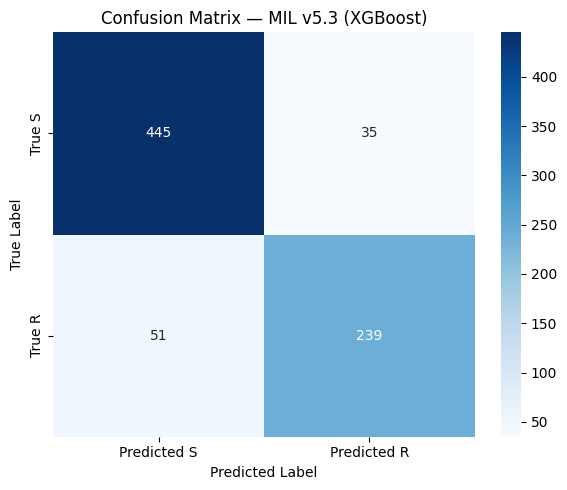

In [ ]:
from sklearn.metrics import precision_recall_fscore_support, roc_auc_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import joblib

print("\n" + "="*55)
print("ENTRENANDO XGBOOST (MIL v5.3)")
print("="*55)

# Entrenar XGBoost
clf_xgb = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.05,
    objective='binary:logistic',
    eval_metric='auc',
    random_state=42
)

clf_xgb.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

# Guardar modelo
joblib.dump(clf_xgb, RUTA_XGB)
print(f"Modelo XGBoost guardado en: {RUTA_XGB}")

# Predecir
y_pred_xgb = clf_xgb.predict(X_val)
y_score_xgb = clf_xgb.predict_proba(X_val)[:, 1]

auc_xgb = roc_auc_score(y_val, y_score_xgb)
acc_xgb = sum(p==t for p,t in zip(y_pred_xgb, y_val)) / len(y_val)
prec_xgb, rec_xgb, f1_xgb, _ = precision_recall_fscore_support(y_val, y_pred_xgb, labels=[0, 1])

print("\nRESULTADOS FINALES - MIL v5.3 (XGBoost)")
print(classification_report(y_val, y_pred_xgb, target_names=["Susceptible (S)", "Resistente (R)"]))
print(f"ROC AUC: {auc_xgb:.4f}")

# Matriz de confusion
cm_xgb = confusion_matrix(y_val, y_pred_xgb)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_xgb, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Predicted S", "Predicted R"],
            yticklabels=["True S", "True R"])
plt.title("Confusion Matrix — MIL v5.3 (XGBoost)")
plt.ylabel("True Label"); plt.xlabel("Predicted Label")
plt.tight_layout()
plt.savefig(f"{RUTA_BASE}/confusion_matrix_v5.3.png", dpi=120)
plt.show()

## Celda 13b — Guardar predicciones para curvas ROC reales
Guarda `y_score_xgb` e `y_val` como archivos `.npy` en Drive.
Necesario para regenerar la Figura 2 con datos reales (no sintéticos).

In [ ]:
import numpy as np

# ── Guardar predicciones MIL v5.3 para figura ROC ─────────────────────────
# y_score_xgb : probabilidades predichas (float, shape [N])
# y_val        : etiquetas reales        (int,   shape [N])
np.save(f"{RUTA_BASE}/roc_y_score_mil_v53.npy",  y_score_xgb)
np.save(f"{RUTA_BASE}/roc_y_true.npy",            np.array(y_val))

print(f"Guardado roc_y_score_mil_v53.npy  — shape: {y_score_xgb.shape}")
print(f"Guardado roc_y_true.npy           — shape: {np.array(y_val).shape}")
print(f"Distribución de clases: S={int((np.array(y_val)==0).sum())}  R={int((np.array(y_val)==1).sum())}")
print("\nNOTA: Para la Figura 2 multi-modelo necesitas también guardar")
print("      las predicciones de los baselines (TF-IDF RF, ML-iAMR XGB,")
print("      NTv3 MLP) desde sus respectivos notebooks con:")
print("      np.save('roc_y_score_<modelo>.npy', y_score_<modelo>)")


Guardado roc_y_score_mil_v53.npy  — shape: (770,)
Guardado roc_y_true.npy           — shape: (770,)
Distribución de clases: S=480  R=290

NOTA: Para la Figura 2 multi-modelo necesitas también guardar
      las predicciones de los baselines (TF-IDF RF, ML-iAMR XGB,
      NTv3 MLP) desde sus respectivos notebooks con:
      np.save('roc_y_score_<modelo>.npy', y_score_<modelo>)


# CELDA B1 — Cargar metadatos y construir df_pred para v5.3


País disponible para 0 aislados
✅ Dataset listo: 770 aislados
   FN: 51 | FP: 35
ANÁLISIS 1: FALSE NEGATIVE PROFILING — MIL v5.3 (XGBoost)

  [Carbapenemase]  N=124 (R=51, S=73)
    Accuracy:0.8629 | AUC:0.9589 | Recall(R):0.7451
    VME:0.2549 (13 FN) | ME:0.0548


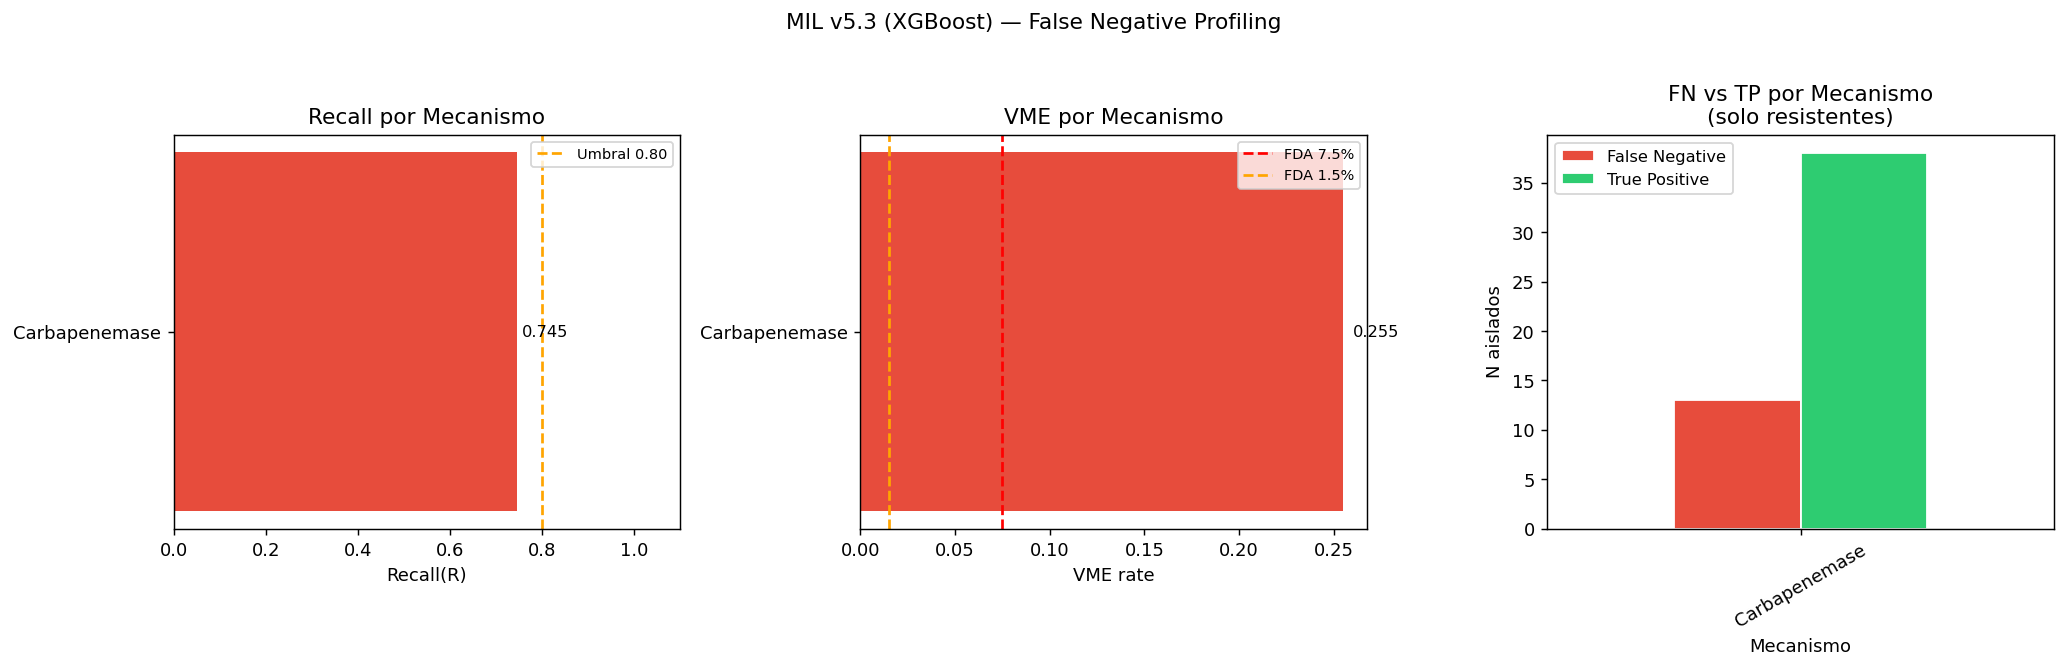

✅ Figura guardada
ANÁLISIS 2: SESGO GEOGRÁFICO — MIL v5.3 (XGBoost)
⚠️  Sin metadatos de país — sube cepasv2.xlsx a RUTA_BASE en Drive
ANÁLISIS 3: CALIBRACIÓN — MIL v5.3 (XGBoost)
Brier Score : 0.0739
ECE         : 0.0377  (3.8% error promedio)
✅ Calibración EXCELENTE


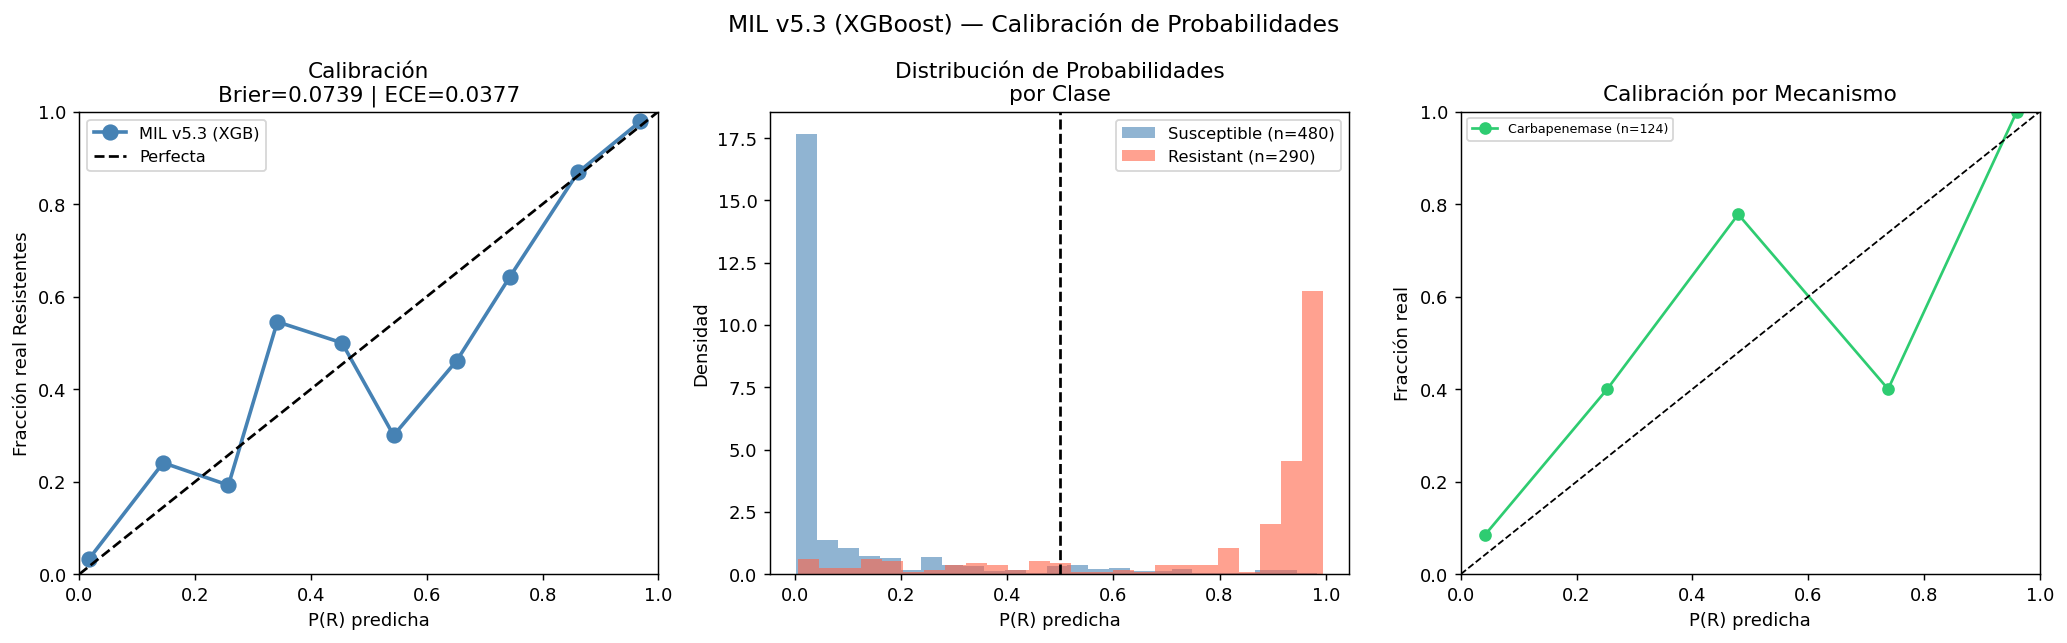


RESUMEN — What Is Not Promising | MIL v5.3 (XGBoost)

📊 Global: AUC=0.9621 | Acc=0.8883 | VME=0.1759
🔴 Mecanismo más problemático: Carbapenemase VME=0.2549
⚠️  NOT PROMISING: ['Carbapenemase'] (VME > 20%)
📊 Calibración: Brier=0.0739 | ECE=0.0377

📁 Archivos en: ../results


In [ ]:
import re, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["figure.dpi"] = 130
from sklearn.metrics import (accuracy_score, recall_score,
                              roc_auc_score)
from sklearn.calibration import calibration_curve

RUTA_AUDITORIA = os.path.join(RUTA_BASE, "data", "Auditoria_Final_Armonizada.xlsx") if os.path.exists(os.path.join(RUTA_BASE, "data", "Auditoria_Final_Armonizada.xlsx")) else "../data/Auditoria_Final_Armonizada.xlsx"
RUTA_CEPAS     = os.path.join(RUTA_BASE, "data", "cepasv2.xlsx") if os.path.exists(os.path.join(RUTA_BASE, "data", "cepasv2.xlsx")) else "../data/cepasv2.xlsx"
RUTA_ANALISIS  = f"{RUTA_BASE}/analisis_not_promising_v5.3"
os.makedirs(RUTA_ANALISIS, exist_ok=True)

# — Recuperar genome_ids del val_loader en el mismo orden —
genome_ids_val = []
for batch in val_loader:
    genome_ids_val.append(batch["genome_id"][0])

# Verificar que el orden coincide con X_val / y_val
assert len(genome_ids_val) == len(y_val), \
    f"Mismatch: {len(genome_ids_val)} genome_ids vs {len(y_val)} labels"

# Construir df_pred con las predicciones del XGBoost
df_pred = pd.DataFrame({
    "genome_id"  : genome_ids_val,
    "label_real" : y_val,          # array del val set
    "pred_label" : y_pred_xgb,     # predicciones XGBoost
    "prob_R"     : y_score_xgb,    # probabilidades XGBoost
})

def norm_id(s):
    return str(s).replace("GCF_", "GCA_")

df_pred["genome_id_norm"] = df_pred["genome_id"].apply(norm_id)
df_pred["FN"] = ((df_pred["label_real"]==1) & (df_pred["pred_label"]==0)).astype(int)
df_pred["FP"] = ((df_pred["label_real"]==0) & (df_pred["pred_label"]==1)).astype(int)
df_pred["error_type"] = "Correct"
df_pred.loc[df_pred["FN"]==1, "error_type"] = "False Negative (VME)"
df_pred.loc[df_pred["FP"]==1, "error_type"] = "False Positive (ME)"

# — Cargar y parsear auditoría —
audit = pd.read_excel(RUTA_AUDITORIA)
audit["accession_norm"] = audit["genome_id"].apply(norm_id)

def parse_mechs(s):
    if pd.isna(s): return {}
    result = {}
    for part in str(s).split(";"):
        m = re.match(r"(.+?)\s*\((\d+)\)", part.strip())
        if m: result[m.group(1).strip()] = int(m.group(2))
    return result

audit["mech_dict"]      = audit["Mechanisms"].apply(parse_mechs)
audit["n_efflux"]       = audit["mech_dict"].apply(lambda d: d.get("antibiotic efflux", 0))
audit["n_inactivation"] = audit["mech_dict"].apply(lambda d: d.get("antibiotic inactivation", 0))
audit["n_target_alter"] = audit["mech_dict"].apply(lambda d: d.get("antibiotic target alteration", 0))

def dominant_mech(row):
    if row["Carbapenemase"] == 1:                                         return "Carbapenemase"
    if row["n_efflux"] > row["n_inactivation"] and row["n_efflux"] > row["n_target_alter"]:
        return "Efflux-dominant"
    if row["n_inactivation"] > 0:                                         return "Inactivation (no carb)"
    return "Target alteration"

audit["dominant_mech"] = audit.apply(dominant_mech, axis=1)

df_an = df_pred.merge(
    audit[["accession_norm","Carbapenemase","dominant_mech",
           "n_efflux","n_inactivation","n_target_alter","Strict_Hits"]],
    left_on="genome_id_norm", right_on="accession_norm", how="left"
)

try:
    cepas = pd.read_excel(RUTA_CEPAS)
    cepas["assembly_norm"] = cepas["assembly_accession"].apply(
        lambda x: str(x).replace("GCF_","GCA_") if pd.notna(x) else x
    )
    df_an = df_an.merge(
        cepas[["assembly_norm","country","collection_date"]],
        left_on="genome_id_norm", right_on="assembly_norm", how="left"
    )
    print(f"País disponible para {df_an['country'].notna().sum()} aislados")
except Exception as e:
    print(f"cepasv2.xlsx no disponible: {e}")
    df_an["country"] = None
    df_an["collection_date"] = None

print(f"✅ Dataset listo: {len(df_an)} aislados")
print(f"   FN: {df_an['FN'].sum()} | FP: {df_an['FP'].sum()}")
df_an.to_csv(f"{RUTA_ANALISIS}/dataset_analisis_v5.3.csv", index=False)


# ────────────────────────────────────────────────────────────
# CELDA B2 — Análisis 1: False Negative Profiling (v5.3 XGB)
# ────────────────────────────────────────────────────────────
print("=" * 60)
print("ANÁLISIS 1: FALSE NEGATIVE PROFILING — MIL v5.3 (XGBoost)")
print("=" * 60)

df_mech = df_an[df_an["dominant_mech"].notna()].copy()
rows_mech = []

for mech, grp in df_mech.groupby("dominant_mech"):
    n_R = (grp["label_real"]==1).sum()
    n_S = (grp["label_real"]==0).sum()
    acc = accuracy_score(grp["label_real"], grp["pred_label"])
    vme = grp["FN"].sum() / max(n_R, 1)
    me  = grp["FP"].sum() / max(n_S, 1)
    rec = recall_score(grp["label_real"], grp["pred_label"], zero_division=0)
    try:    auc = roc_auc_score(grp["label_real"], grp["prob_R"])
    except: auc = float("nan")
    rows_mech.append({"Mechanism": mech, "N": len(grp), "N_R": n_R, "N_S": n_S,
                      "Accuracy": acc, "ROC_AUC": auc, "Recall_R": rec,
                      "VME_rate": vme, "ME_rate": me,
                      "n_FN": grp["FN"].sum(), "n_FP": grp["FP"].sum()})
    print(f"\n  [{mech}]  N={len(grp)} (R={n_R}, S={n_S})")
    print(f"    Accuracy:{acc:.4f} | AUC:{auc:.4f} | Recall(R):{rec:.4f}")
    print(f"    VME:{vme:.4f} ({grp['FN'].sum()} FN) | ME:{me:.4f}")

df_mech_sum = pd.DataFrame(rows_mech)
df_mech_sum.to_csv(f"{RUTA_ANALISIS}/fn_profiling_mecanismo_v5.3.csv", index=False)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
ms = df_mech_sum.sort_values("VME_rate", ascending=False)

ax = axes[0]
colors = ["#e74c3c" if v > 0.3 else "#3498db" for v in ms["Recall_R"]]
b = ax.barh(ms["Mechanism"], ms["Recall_R"], color=colors)
ax.axvline(0.8, color="orange", linestyle="--", lw=1.5, label="Umbral 0.80")
[ax.text(bar.get_width()+0.01, bar.get_y()+bar.get_height()/2,
         f"{v:.3f}", va="center", fontsize=9) for bar, v in zip(b, ms["Recall_R"])]
ax.set_xlabel("Recall(R)"); ax.set_title("Recall por Mecanismo")
ax.legend(fontsize=8); ax.set_xlim(0, 1.1)

ax = axes[1]
colors2 = ["#e74c3c" if v>0.075 else ("#f39c12" if v>0.015 else "#2ecc71") for v in ms["VME_rate"]]
b2 = ax.barh(ms["Mechanism"], ms["VME_rate"], color=colors2)
ax.axvline(0.075, color="red",    linestyle="--", lw=1.5, label="FDA 7.5%")
ax.axvline(0.015, color="orange", linestyle="--", lw=1.5, label="FDA 1.5%")
[ax.text(bar.get_width()+0.005, bar.get_y()+bar.get_height()/2,
         f"{v:.3f}", va="center", fontsize=9) for bar, v in zip(b2, ms["VME_rate"])]
ax.set_xlabel("VME rate"); ax.set_title("VME por Mecanismo")
ax.legend(fontsize=8)

ax = axes[2]
resistentes = df_an[df_an["label_real"]==1].copy()
resistentes["tipo"] = resistentes["FN"].map({1: "False Negative", 0: "True Positive"})
if df_an["dominant_mech"].notna().sum() > 0:
    fn_by_m = resistentes.groupby(["dominant_mech","tipo"]).size().unstack(fill_value=0)
    fn_by_m.plot(kind="bar", ax=ax, color=["#e74c3c","#2ecc71"], edgecolor="white")
    ax.set_xlabel("Mecanismo"); ax.set_ylabel("N aislados")
    ax.set_title("FN vs TP por Mecanismo\n(solo resistentes)")
    ax.tick_params(axis="x", rotation=30); ax.legend(fontsize=9)

plt.suptitle("MIL v5.3 (XGBoost) — False Negative Profiling", fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(f"{RUTA_ANALISIS}/analisis1_FN_mecanismo_v5.3.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Figura guardada")


# ────────────────────────────────────────────────────────────
# CELDA B3 — Análisis 2: Geographic Bias (v5.3 XGB)
# ────────────────────────────────────────────────────────────
print("=" * 60)
print("ANÁLISIS 2: SESGO GEOGRÁFICO — MIL v5.3 (XGBoost)")
print("=" * 60)

df_country = df_an[df_an["country"].notna()].copy()

if len(df_country) > 0:
    country_rows = []
    for country, grp in df_country.groupby("country"):
        if len(grp) < 5: continue
        n_R = (grp["label_real"]==1).sum()
        n_S = (grp["label_real"]==0).sum()
        acc = accuracy_score(grp["label_real"], grp["pred_label"])
        vme = grp["FN"].sum() / max(n_R, 1)
        me  = grp["FP"].sum() / max(n_S, 1)
        try:    auc = roc_auc_score(grp["label_real"], grp["prob_R"])
        except: auc = float("nan")
        country_rows.append({"Country": country, "N": len(grp), "N_R": n_R,
                              "Accuracy": acc, "ROC_AUC": auc,
                              "VME_rate": vme, "ME_rate": me})
    df_cs = pd.DataFrame(country_rows).sort_values("VME_rate", ascending=False)
    print(df_cs.to_string(index=False, float_format=lambda x: f"{x:.3f}"))
    df_cs.to_csv(f"{RUTA_ANALISIS}/sesgo_geografico_v5.3.csv", index=False)

    top = df_cs.head(min(15, len(df_cs)))
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    ax = axes[0]
    top_a = top.sort_values("Accuracy")
    colors = ["#e74c3c" if v<0.80 else "#3498db" for v in top_a["Accuracy"]]
    b = ax.barh(top_a["Country"], top_a["Accuracy"], color=colors)
    ax.axvline(0.88, color="green", linestyle="--", lw=1.5, label="Global v5.3")
    [ax.text(bar.get_width()+0.01, bar.get_y()+bar.get_height()/2,
             f"n={int(r['N'])}", va="center", fontsize=8)
     for bar, (_, r) in zip(b, top_a.iterrows())]
    ax.set_xlabel("Accuracy"); ax.set_title("Accuracy por País — v5.3 (XGB)")
    ax.legend(fontsize=8)

    ax = axes[1]
    top_v = top.sort_values("VME_rate", ascending=True)
    colors2 = ["#e74c3c" if v>0.075 else ("#f39c12" if v>0.015 else "#2ecc71")
               for v in top_v["VME_rate"]]
    ax.barh(top_v["Country"], top_v["VME_rate"], color=colors2)
    ax.axvline(0.075, color="red",    linestyle="--", lw=1.5, label="FDA 7.5%")
    ax.axvline(0.015, color="orange", linestyle="--", lw=1.5, label="FDA 1.5%")
    ax.set_xlabel("VME rate"); ax.set_title("VME rate por País — v5.3 (XGB)")
    ax.legend(fontsize=8)

    plt.suptitle("MIL v5.3 (XGBoost) — Sesgo Geográfico", fontsize=13)
    plt.tight_layout()
    plt.savefig(f"{RUTA_ANALISIS}/analisis2_geografico_v5.3.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("⚠️  Sin metadatos de país — sube cepasv2.xlsx a RUTA_BASE en Drive")


# ────────────────────────────────────────────────────────────
# CELDA B4 — Análisis 3: Probability Calibration (v5.3 XGB)
# ────────────────────────────────────────────────────────────
print("=" * 60)
print("ANÁLISIS 3: CALIBRACIÓN — MIL v5.3 (XGBoost)")
print("=" * 60)

y_true_arr  = np.array(df_an["label_real"].values)
y_score_arr = np.array(df_an["prob_R"].values)

brier = np.mean((y_score_arr - y_true_arr)**2)
bins  = np.linspace(0, 1, 11)
ece   = 0.0
bin_data = []
for i in range(10):
    mask = (y_score_arr >= bins[i]) & (y_score_arr < bins[i+1])
    if mask.sum() == 0: continue
    fp   = y_true_arr[mask].mean()
    mp   = y_score_arr[mask].mean()
    ece += (mask.sum()/len(y_true_arr)) * abs(fp - mp)
    bin_data.append({"bin_center": (bins[i]+bins[i+1])/2,
                     "frac_pos": fp, "mean_pred": mp, "n": mask.sum()})
df_bins = pd.DataFrame(bin_data)

print(f"Brier Score : {brier:.4f}")
print(f"ECE         : {ece:.4f}  ({ece*100:.1f}% error promedio)")
if   ece < 0.05: print("✅ Calibración EXCELENTE")
elif ece < 0.10: print("✅ Calibración BUENA")
elif ece < 0.15: print("⚠️  Calibración MODERADA")
else:            print("❌ Calibración POBRE — NOT PROMISING")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ax = axes[0]
if len(df_bins) > 0:
    ax.plot(df_bins["mean_pred"], df_bins["frac_pos"], "o-",
            color="steelblue", lw=2, markersize=8, label="MIL v5.3 (XGB)")
ax.plot([0,1],[0,1],"k--",lw=1.5, label="Perfecta")
ax.set_xlabel("P(R) predicha"); ax.set_ylabel("Fracción real Resistentes")
ax.set_title(f"Calibración\nBrier={brier:.4f} | ECE={ece:.4f}")
ax.legend(fontsize=9); ax.set_xlim(0,1); ax.set_ylim(0,1)

ax = axes[1]
s_p = df_an[df_an["label_real"]==0]["prob_R"]
r_p = df_an[df_an["label_real"]==1]["prob_R"]
ax.hist(s_p, bins=25, alpha=0.6, color="steelblue",
        label=f"Susceptible (n={len(s_p)})", density=True)
ax.hist(r_p, bins=25, alpha=0.6, color="tomato",
        label=f"Resistant (n={len(r_p)})", density=True)
ax.axvline(0.5, color="black", linestyle="--", lw=1.5)
ax.set_xlabel("P(R) predicha"); ax.set_ylabel("Densidad")
ax.set_title("Distribución de Probabilidades\npor Clase")
ax.legend(fontsize=9)

ax = axes[2]
mech_colors = {"Carbapenemase": "#2ecc71", "Efflux-dominant": "#e74c3c",
               "Inactivation (no carb)": "#f39c12", "Target alteration": "#9b59b6"}
if df_an["dominant_mech"].notna().sum() > 0:
    for mech, grp in df_an[df_an["dominant_mech"].notna()].groupby("dominant_mech"):
        if len(grp) < 5: continue
        try:
            frac, mpred = calibration_curve(grp["label_real"], grp["prob_R"],
                                            n_bins=5, strategy="uniform")
            ax.plot(mpred, frac, "o-", label=f"{mech} (n={len(grp)})",
                    color=mech_colors.get(mech,"gray"), lw=1.5, markersize=6)
        except: pass
ax.plot([0,1],[0,1],"k--",lw=1)
ax.set_xlabel("P(R) predicha"); ax.set_ylabel("Fracción real")
ax.set_title("Calibración por Mecanismo")
ax.legend(fontsize=7); ax.set_xlim(0,1); ax.set_ylim(0,1)

plt.suptitle("MIL v5.3 (XGBoost) — Calibración de Probabilidades", fontsize=13)
plt.tight_layout()
plt.savefig(f"{RUTA_ANALISIS}/analisis3_calibracion_v5.3.png", dpi=150, bbox_inches="tight")
plt.show()

# — Resumen final —
print("\n" + "=" * 65)
print("RESUMEN — What Is Not Promising | MIL v5.3 (XGBoost)")
print("=" * 65)
n_R   = (df_an["label_real"]==1).sum()
vme_g = df_an["FN"].sum() / max(n_R, 1)
print(f"\n📊 Global: AUC={auc_xgb:.4f} | Acc={acc_xgb:.4f} | VME={vme_g:.4f}")
if len(df_mech_sum) > 0:
    worst = df_mech_sum.sort_values("VME_rate", ascending=False).iloc[0]
    print(f"🔴 Mecanismo más problemático: {worst['Mechanism']} VME={worst['VME_rate']:.4f}")
    not_p = df_mech_sum[df_mech_sum["VME_rate"] > 0.20]
    if len(not_p) > 0:
        print(f"⚠️  NOT PROMISING: {not_p['Mechanism'].tolist()} (VME > 20%)")
print(f"📊 Calibración: Brier={brier:.4f} | ECE={ece:.4f}")
if ece >= 0.15: print("⚠️  NOT PROMISING: calibración pobre")
print(f"\n📁 Archivos en: {RUTA_ANALISIS}")


In [ ]:
print(f"Total val set: {len(df_an)}")
print(f"Con mecanismo asignado: {df_an['dominant_mech'].notna().sum()}")
print(f"Sin mecanismo (join fallido): {df_an['dominant_mech'].isna().sum()}")
print(df_an[df_an['dominant_mech'].isna()]['genome_id'].head(5).tolist())

Total val set: 770
Con mecanismo asignado: 124
Sin mecanismo (join fallido): 646
['Kp_ertapenem_R_015710-delta-acyT-delta-pyt_573_81410', 'Kp_ertapenem_R_101_573_24244', 'Kp_ertapenem_R_15006GOR17_573_81604', 'Kp_ertapenem_R_159Kpn_573_78755', 'Kp_ertapenem_R_18_573_79052']


País disponible para 644 aislados
✅ Dataset listo: 770 aislados
   Con mecanismo asignado: 124
   Sin mecanismo (join fallido): 646
   FN: 51 | FP: 35
   Primeros IDs sin match: ['Kp_ertapenem_R_015710-delta-acyT-delta-pyt_573_81410', 'Kp_ertapenem_R_101_573_24244', 'Kp_ertapenem_R_15006GOR17_573_81604', 'Kp_ertapenem_R_159Kpn_573_78755', 'Kp_ertapenem_R_18_573_79052']
ANÁLISIS 1: FALSE NEGATIVE PROFILING — MIL v5.3 (XGBoost)

  [Carbapenemase]  N=124 (R=51, S=73)
    Accuracy: 0.8629 | AUC: 0.9589 | Recall(R): 0.7451
    VME: 0.2549 (13 FN) | ME: 0.0548


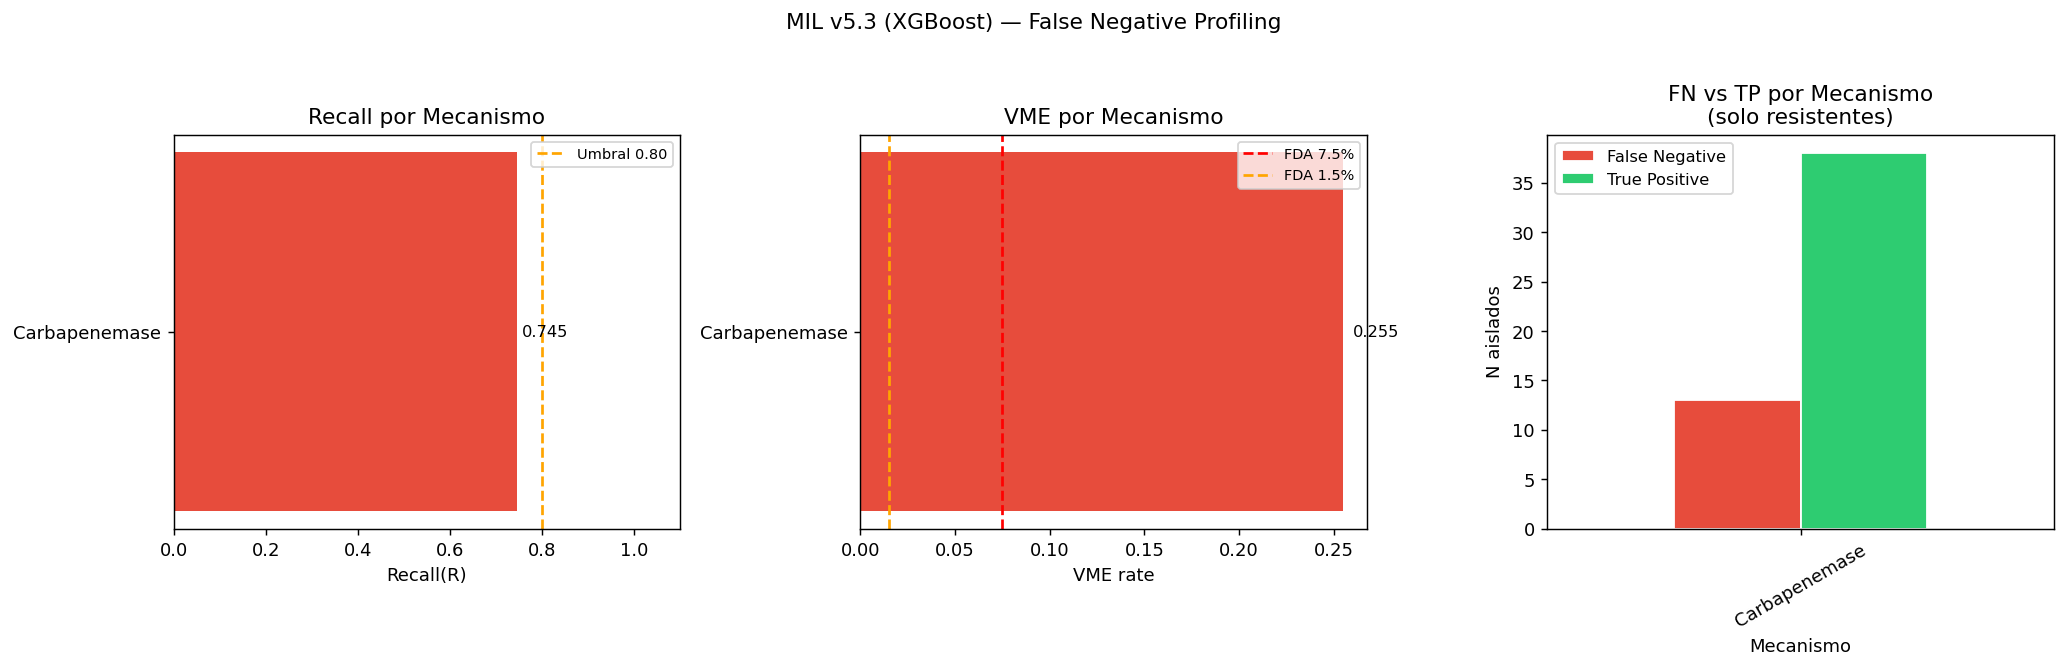

✅ Figura guardada
ANÁLISIS 2: SESGO GEOGRÁFICO — MIL v5.3 (XGBoost)
Country   N  N_R  N_S  Accuracy  ROC_AUC  VME_rate  ME_rate
    USA 644  256  388     0.894    0.967     0.156    0.072


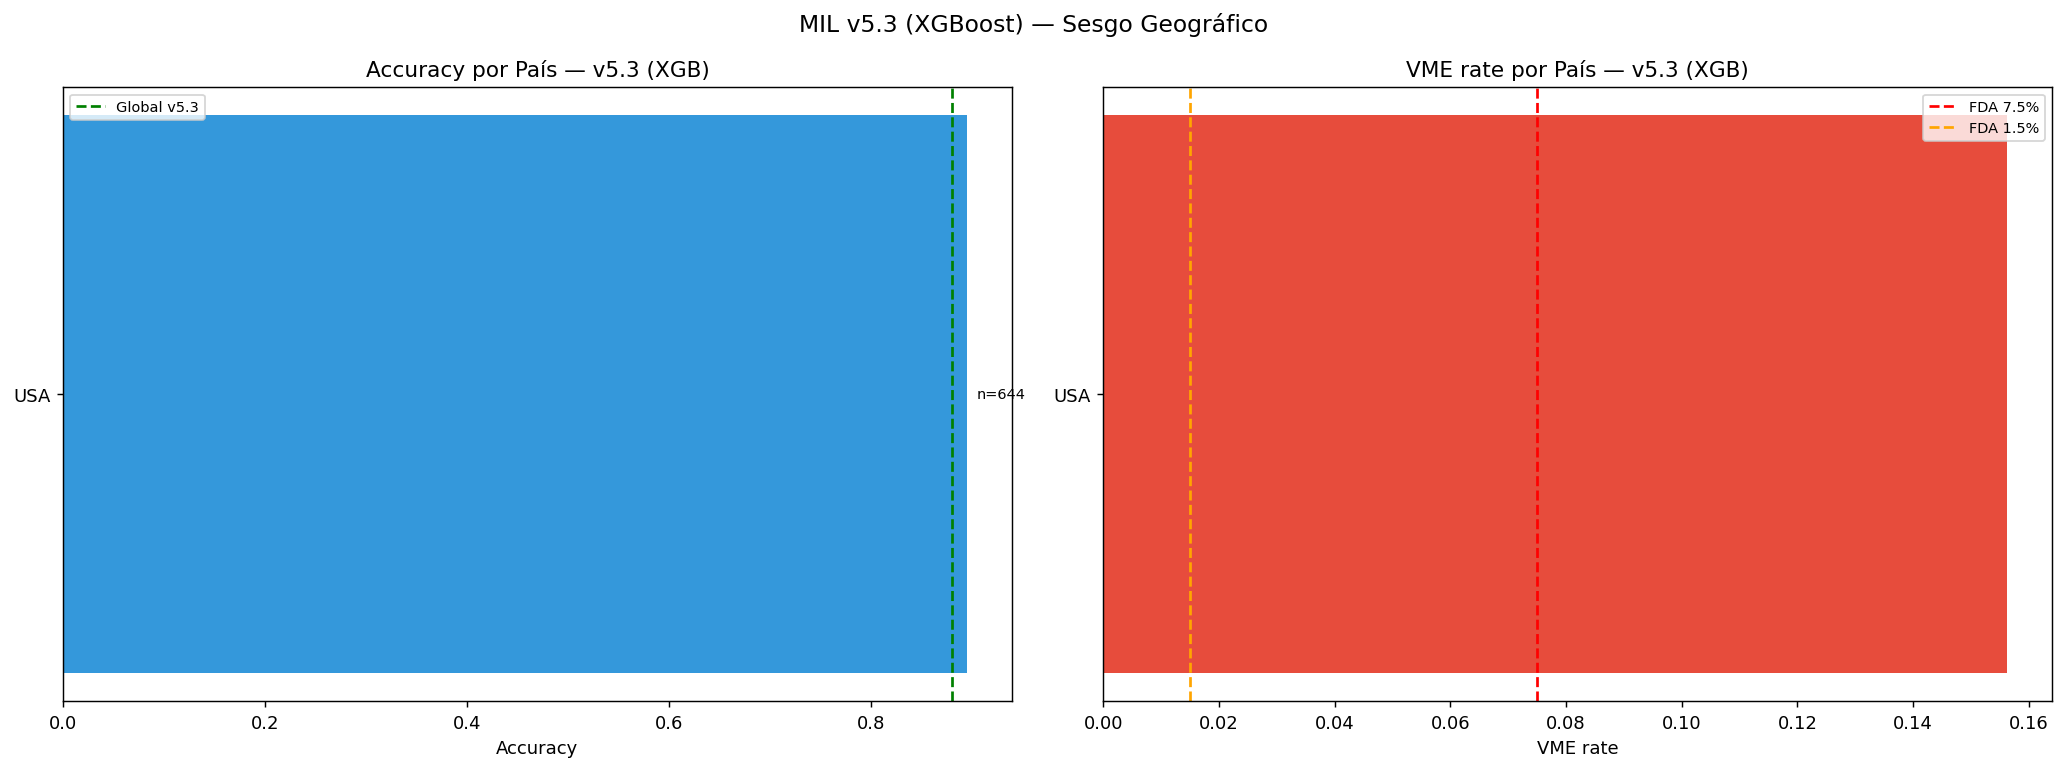

ANÁLISIS 3: CALIBRACIÓN — MIL v5.3 (XGBoost)
Brier Score : 0.0739
ECE         : 0.0377  (3.8% error promedio)
✅ Calibración EXCELENTE


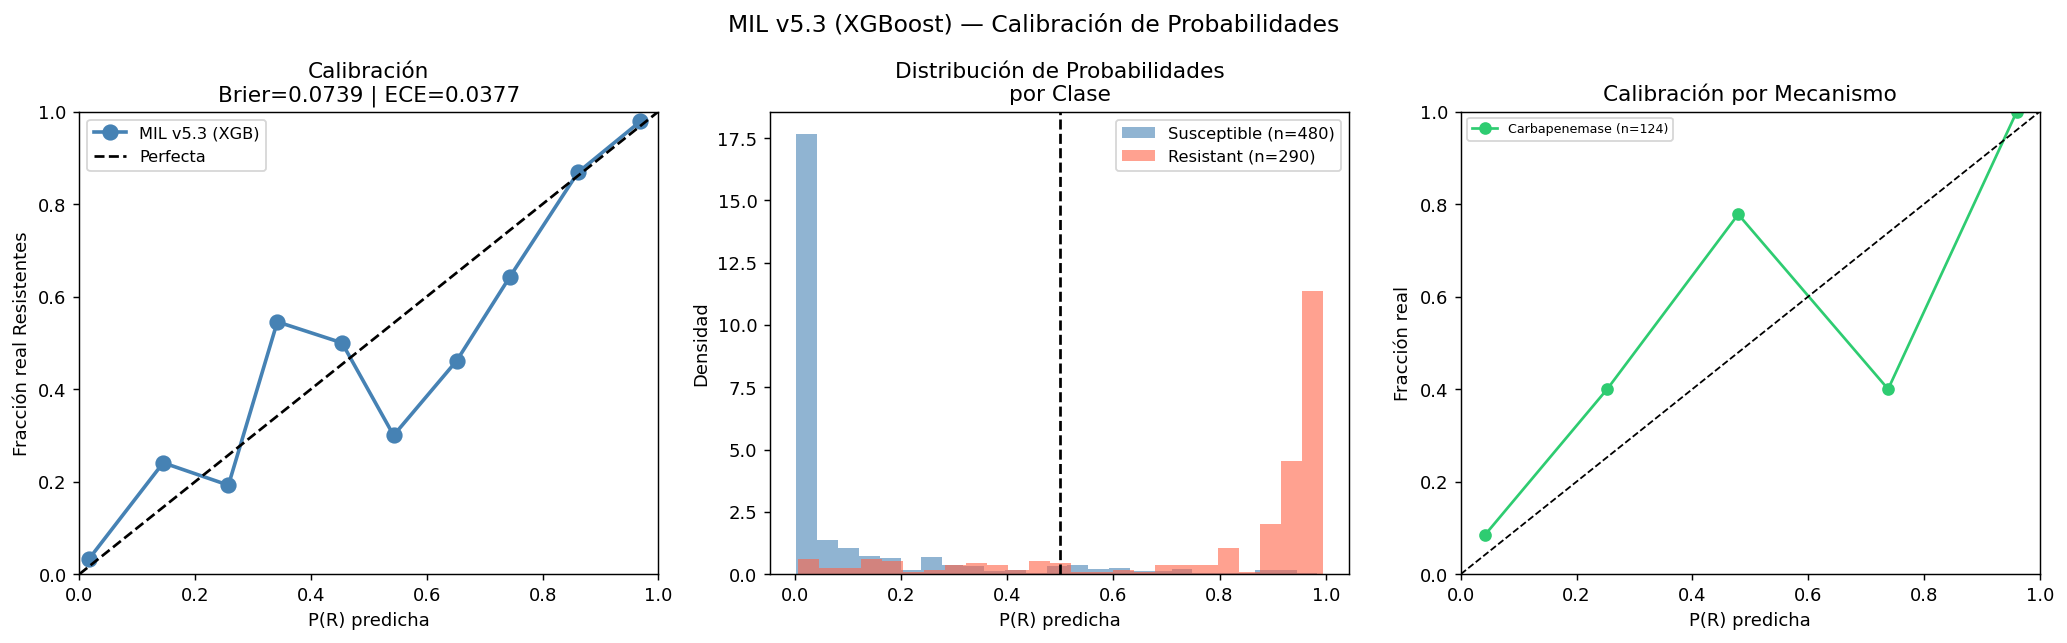


RESUMEN — What Is Not Promising | MIL v5.3 (XGBoost)

📊 Global: AUC=0.9621 | Acc=0.8883 | VME=0.1759
🔴 Mecanismo más problemático: Carbapenemase VME=0.2549
⚠️  NOT PROMISING: ['Carbapenemase'] (VME > 20%)
📊 Calibración: Brier=0.0739 | ECE=0.0377

📁 Archivos en: ../results


In [ ]:
import re
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams["figure.dpi"] = 130

from sklearn.metrics import accuracy_score, recall_score, roc_auc_score
from sklearn.calibration import calibration_curve


# ============================================================
# RUTAS
# ============================================================
def first_existing(paths):
    for p in paths:
        if p and os.path.exists(p):
            return p
    return paths[0]

RUTA_AUDITORIA = first_existing([
    "../data/Auditoria_Final_Armonizada.xlsx",
    os.path.join(RUTA_BASE, "Auditoria_Final_Armonizada.xlsx"),
])

RUTA_CEPAS = first_existing([
    "../data/cepasv2.xlsx",
    os.path.join(RUTA_BASE, "cepasv2.xlsx"),
])

RUTA_MAPEO = first_existing([
    os.path.join(RUTA_BASE, "mapeo_ids.xlsx"),   # opcional: puente manual entre IDs
    ""
])

RUTA_ANALISIS = os.path.join(RUTA_BASE, "analisis_not_promising_v5.3")
os.makedirs(RUTA_ANALISIS, exist_ok=True)


# ============================================================
# HELPERS DE IDS
# ============================================================
def norm_id(s):
    """Normaliza GCF -> GCA y limpia espacios."""
    if pd.isna(s):
        return np.nan
    s = str(s).strip()
    s = s.replace("GCF_", "GCA_")
    return s

def extract_accession(s):
    """
    Extrae una accession tipo GCA_000000000.0 / GCF_000000000.0 si existe
    dentro de cualquier string. Si no existe, devuelve NaN.
    """
    if pd.isna(s):
        return np.nan
    s = str(s)
    m = re.search(r"(GCA_\d+\.\d+|GCF_\d+\.\d+|GCA_\d+|GCF_\d+)", s)
    if not m:
        return np.nan
    return norm_id(m.group(1))

def guess_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

def safe_roc_auc(y_true, y_score):
    try:
        if len(np.unique(y_true)) < 2:
            return np.nan
        return roc_auc_score(y_true, y_score)
    except Exception:
        return np.nan


# ============================================================
# 1) PREDICCIONES DEL VAL SET
# ============================================================
genome_ids_val = []
for batch in val_loader:
    genome_ids_val.append(batch["genome_id"][0])

assert len(genome_ids_val) == len(y_val), (
    f"Mismatch: {len(genome_ids_val)} genome_ids vs {len(y_val)} labels"
)

df_pred = pd.DataFrame({
    "genome_id": genome_ids_val,
    "label_real": np.asarray(y_val),
    "pred_label": np.asarray(y_pred_xgb),
    "prob_R": np.asarray(y_score_xgb),
})

df_pred["genome_id_norm"] = df_pred["genome_id"].apply(norm_id)
df_pred["genome_id_acc"] = df_pred["genome_id"].apply(extract_accession)

df_pred["FN"] = ((df_pred["label_real"] == 1) & (df_pred["pred_label"] == 0)).astype(int)
df_pred["FP"] = ((df_pred["label_real"] == 0) & (df_pred["pred_label"] == 1)).astype(int)
df_pred["error_type"] = "Correct"
df_pred.loc[df_pred["FN"] == 1, "error_type"] = "False Negative (VME)"
df_pred.loc[df_pred["FP"] == 1, "error_type"] = "False Positive (ME)"


# ============================================================
# 2) CARGA DE AUDITORÍA Y PARSEO DE MECANISMOS
# ============================================================
audit = pd.read_excel(RUTA_AUDITORIA)

# Claves posibles de auditoría
audit["genome_id_norm"] = audit["genome_id"].apply(norm_id)
audit["genome_id_acc"] = audit["genome_id"].apply(extract_accession)

def parse_mechs(s):
    """
    Convierte una cadena tipo:
      'antibiotic efflux (3); antibiotic inactivation (2)'
    en un diccionario:
      {'antibiotic efflux': 3, 'antibiotic inactivation': 2}
    """
    if pd.isna(s):
        return {}
    result = {}
    for part in str(s).split(";"):
        m = re.match(r"(.+?)\s*\((\d+)\)", part.strip())
        if m:
            result[m.group(1).strip()] = int(m.group(2))
    return result

audit["mech_dict"] = audit["Mechanisms"].apply(parse_mechs)
audit["n_efflux"] = audit["mech_dict"].apply(lambda d: d.get("antibiotic efflux", 0))
audit["n_inactivation"] = audit["mech_dict"].apply(lambda d: d.get("antibiotic inactivation", 0))
audit["n_target_alter"] = audit["mech_dict"].apply(lambda d: d.get("antibiotic target alteration", 0))

def dominant_mech(row):
    # Prioridad clínica/biológica simplificada
    if row.get("Carbapenemase", 0) == 1:
        return "Carbapenemase"
    if row["n_efflux"] > row["n_inactivation"] and row["n_efflux"] > row["n_target_alter"]:
        return "Efflux-dominant"
    if row["n_inactivation"] > 0:
        return "Inactivation (no carb)"
    if row["n_target_alter"] > 0:
        return "Target alteration"
    return np.nan

audit["dominant_mech"] = audit.apply(dominant_mech, axis=1)

audit_cols = [
    "genome_id_norm",
    "genome_id_acc",
    "Carbapenemase",
    "dominant_mech",
    "n_efflux",
    "n_inactivation",
    "n_target_alter",
    "Strict_Hits",
]
audit_lu = audit[audit_cols].drop_duplicates(subset=["genome_id_norm"]).copy()


# ============================================================
# 3) MAPEO OPCIONAL ENTRE IDs INTERNOS Y ACCESSIONS
# ============================================================
# Si tienes un archivo puente, este bloque lo aprovecha.
# Debe tener dos columnas: una para el ID del dataset/modelo y otra para el ID del genoma/auditoría.
map_df = None
if RUTA_MAPEO and os.path.exists(RUTA_MAPEO):
    try:
        tmp = pd.read_excel(RUTA_MAPEO)
        c_left = guess_col(tmp, ["sample_id", "genome_id", "id", "strain_id", "query_id"])
        c_right = guess_col(tmp, ["audit_genome_id", "genome_id_audit", "assembly_accession", "gca", "gcf", "target_id"])

        if c_left and c_right:
            map_df = tmp[[c_left, c_right]].dropna().drop_duplicates().copy()
            map_df.columns = ["sample_id_raw", "audit_id_raw"]
            map_df["sample_id_norm"] = map_df["sample_id_raw"].apply(norm_id)
            map_df["audit_id_norm"] = map_df["audit_id_raw"].apply(norm_id)
            map_df["audit_id_acc"] = map_df["audit_id_raw"].apply(extract_accession)
            print(f"✅ Archivo puente cargado: {RUTA_MAPEO}")
            print(f"   Filas puente: {len(map_df)}")
        else:
            print("⚠️  Archivo puente encontrado, pero no se pudieron inferir las columnas.")
            map_df = None
    except Exception as e:
        print(f"⚠️  No se pudo leer el archivo puente: {e}")
        map_df = None


# ============================================================
# 4) CONSTRUIR df_an CON JOIN ROBUSTO
# ============================================================
df_an = df_pred.copy()

# 4.1. Join directo por genome_id_norm si coincide con auditoría
df_an = df_an.merge(
    audit_lu,
    left_on="genome_id_norm",
    right_on="genome_id_norm",
    how="left",
    suffixes=("", "_audit")
)

# 4.2. Si hay archivo puente, usarlo para completar los que no empataron
if map_df is not None:
    # Traer la clave auditada al df_pred
    df_an = df_an.merge(
        map_df[["sample_id_norm", "audit_id_norm", "audit_id_acc"]],
        left_on="genome_id_norm",
        right_on="sample_id_norm",
        how="left"
    )

    # Rellenar con la clave mapeada si existe
    mask_missing = df_an["dominant_mech"].isna() & df_an["audit_id_norm"].notna()

    if mask_missing.any():
        tmp_fix = df_an.loc[mask_missing, ["audit_id_norm", "audit_id_acc"]].copy()
        tmp_fix["join_key"] = tmp_fix["audit_id_norm"].fillna(tmp_fix["audit_id_acc"])

        audit_alt = audit_lu.copy()
        audit_alt = audit_alt.rename(columns={"genome_id_norm": "join_key_norm", "genome_id_acc": "join_key_acc"})

        # Primer intento con audit_id_norm
        fix1 = tmp_fix.merge(
            audit_lu,
            left_on="audit_id_norm",
            right_on="genome_id_norm",
            how="left"
        )

        # Segundo intento con accession extraída
        still_missing = fix1["dominant_mech"].isna() & fix1["audit_id_acc"].notna()
        if still_missing.any():
            fix2 = fix1.loc[still_missing, ["audit_id_acc"]].merge(
                audit_lu,
                left_on="audit_id_acc",
                right_on="genome_id_norm",
                how="left",
                suffixes=("", "_x")
            )
            cols_to_fill = ["Carbapenemase", "dominant_mech", "n_efflux", "n_inactivation", "n_target_alter", "Strict_Hits"]
            for col in cols_to_fill:
                df_an.loc[mask_missing[mask_missing].index[still_missing], col] = fix2[col].values

            # Rellenar también genome_id_norm si hiciera falta
            df_an.loc[mask_missing[mask_missing].index[still_missing], "genome_id_norm"] = fix2["genome_id_norm"].values

# 4.3. Join geográfico por cepas
try:
    cepas = pd.read_excel(RUTA_CEPAS)
    col_acc = guess_col(cepas, ["assembly_accession", "genome_id", "accession", "assembly"])
    col_country = guess_col(cepas, ["country", "Country", "pais", "país"])
    col_date = guess_col(cepas, ["collection_date", "date", "collection", "year"])

    if col_acc is None:
        raise ValueError("No se encontró una columna de accession en cepasv2.xlsx")

    cepas["assembly_norm"] = cepas[col_acc].apply(norm_id)
    cepas["assembly_acc"] = cepas[col_acc].apply(extract_accession)

    cepas_cols = ["assembly_norm", "assembly_acc"]
    if col_country:
        cepas_cols.append(col_country)
    if col_date:
        cepas_cols.append(col_date)

    cepas_lu = cepas[cepas_cols].drop_duplicates(subset=["assembly_norm"]).copy()

    # Intento 1: por genome_id_norm
    df_an = df_an.merge(
        cepas_lu,
        left_on="genome_id_norm",
        right_on="assembly_norm",
        how="left",
        suffixes=("", "_cepas")
    )

    # Intento 2: completar por accession si quedó vacío
    if df_an["genome_id_acc"].notna().any():
        miss_country = df_an.get(col_country, pd.Series(index=df_an.index, dtype="object")).isna() if col_country else pd.Series(False, index=df_an.index)
        if miss_country.any():
            fix_geo = df_an.loc[miss_country, ["genome_id_acc"]].merge(
                cepas_lu,
                left_on="genome_id_acc",
                right_on="assembly_norm",
                how="left"
            )
            if col_country:
                df_an.loc[miss_country, col_country] = fix_geo[col_country].values
            if col_date:
                df_an.loc[miss_country, col_date] = fix_geo[col_date].values

    n_country = df_an[col_country].notna().sum() if col_country else 0
    print(f"País disponible para {n_country} aislados")
except Exception as e:
    print(f"cepasv2.xlsx no disponible o no usable: {e}")
    df_an["country"] = None
    df_an["collection_date"] = None
    col_country = "country"
    col_date = "collection_date"

# Unificar nombres de columnas geográficas si existen con otro nombre
if "country" not in df_an.columns and col_country in df_an.columns:
    df_an["country"] = df_an[col_country]
if "collection_date" not in df_an.columns and col_date in df_an.columns:
    df_an["collection_date"] = df_an[col_date]

# Reporte de emparejamiento
n_total = len(df_an)
n_mech = df_an["dominant_mech"].notna().sum()
n_na = df_an["dominant_mech"].isna().sum()

print(f"✅ Dataset listo: {n_total} aislados")
print(f"   Con mecanismo asignado: {n_mech}")
print(f"   Sin mecanismo (join fallido): {n_na}")
print(f"   FN: {df_an['FN'].sum()} | FP: {df_an['FP'].sum()}")

unmatched_preview = df_an.loc[df_an["dominant_mech"].isna(), "genome_id"].head(5).tolist()
print(f"   Primeros IDs sin match: {unmatched_preview}")

df_an.to_csv(os.path.join(RUTA_ANALISIS, "dataset_analisis_v5.3.csv"), index=False)


# ============================================================
# 5) ANÁLISIS 1: FALSE NEGATIVE PROFILING
# ============================================================
print("=" * 60)
print("ANÁLISIS 1: FALSE NEGATIVE PROFILING — MIL v5.3 (XGBoost)")
print("=" * 60)

df_mech = df_an[df_an["dominant_mech"].notna()].copy()
rows_mech = []

for mech, grp in df_mech.groupby("dominant_mech"):
    n_R = (grp["label_real"] == 1).sum()
    n_S = (grp["label_real"] == 0).sum()
    acc = accuracy_score(grp["label_real"], grp["pred_label"])
    vme = grp["FN"].sum() / max(n_R, 1)
    me = grp["FP"].sum() / max(n_S, 1)
    rec = recall_score(grp["label_real"], grp["pred_label"], zero_division=0)
    auc = safe_roc_auc(grp["label_real"], grp["prob_R"])

    rows_mech.append({
        "Mechanism": mech,
        "N": len(grp),
        "N_R": n_R,
        "N_S": n_S,
        "Accuracy": acc,
        "ROC_AUC": auc,
        "Recall_R": rec,
        "VME_rate": vme,
        "ME_rate": me,
        "n_FN": int(grp["FN"].sum()),
        "n_FP": int(grp["FP"].sum()),
    })

    print(f"\n  [{mech}]  N={len(grp)} (R={n_R}, S={n_S})")
    print(f"    Accuracy: {acc:.4f} | AUC: {auc:.4f} | Recall(R): {rec:.4f}")
    print(f"    VME: {vme:.4f} ({int(grp['FN'].sum())} FN) | ME: {me:.4f}")

df_mech_sum = pd.DataFrame(rows_mech)
df_mech_sum.to_csv(os.path.join(RUTA_ANALISIS, "fn_profiling_mecanismo_v5.3.csv"), index=False)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

if len(df_mech_sum) > 0:
    ms = df_mech_sum.sort_values("VME_rate", ascending=False)

    ax = axes[0]
    colors = ["#e74c3c" if v > 0.3 else "#3498db" for v in ms["Recall_R"]]
    b = ax.barh(ms["Mechanism"], ms["Recall_R"], color=colors)
    ax.axvline(0.80, color="orange", linestyle="--", lw=1.5, label="Umbral 0.80")
    for bar, v in zip(b, ms["Recall_R"]):
        ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
                f"{v:.3f}", va="center", fontsize=9)
    ax.set_xlabel("Recall(R)")
    ax.set_title("Recall por Mecanismo")
    ax.legend(fontsize=8)
    ax.set_xlim(0, 1.1)

    ax = axes[1]
    colors2 = [
        "#e74c3c" if v > 0.075 else ("#f39c12" if v > 0.015 else "#2ecc71")
        for v in ms["VME_rate"]
    ]
    b2 = ax.barh(ms["Mechanism"], ms["VME_rate"], color=colors2)
    ax.axvline(0.075, color="red", linestyle="--", lw=1.5, label="FDA 7.5%")
    ax.axvline(0.015, color="orange", linestyle="--", lw=1.5, label="FDA 1.5%")
    for bar, v in zip(b2, ms["VME_rate"]):
        ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
                f"{v:.3f}", va="center", fontsize=9)
    ax.set_xlabel("VME rate")
    ax.set_title("VME por Mecanismo")
    ax.legend(fontsize=8)

    ax = axes[2]
    resistentes = df_an[df_an["label_real"] == 1].copy()
    resistentes["tipo"] = resistentes["FN"].map({1: "False Negative", 0: "True Positive"})
    if df_mech["dominant_mech"].notna().sum() > 0:
        fn_by_m = resistentes.groupby(["dominant_mech", "tipo"]).size().unstack(fill_value=0)
        fn_by_m.plot(kind="bar", ax=ax, color=["#e74c3c", "#2ecc71"], edgecolor="white")
        ax.set_xlabel("Mecanismo")
        ax.set_ylabel("N aislados")
        ax.set_title("FN vs TP por Mecanismo\n(solo resistentes)")
        ax.tick_params(axis="x", rotation=30)
        ax.legend(fontsize=9)
else:
    for ax in axes:
        ax.axis("off")
    axes[1].text(
        0.5, 0.5,
        "No hay mecanismos asignados.\nRevisa el join o el archivo puente.",
        ha="center", va="center", fontsize=12
    )

plt.suptitle("MIL v5.3 (XGBoost) — False Negative Profiling", fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(RUTA_ANALISIS, "analisis1_FN_mecanismo_v5.3.png"), dpi=150, bbox_inches="tight")
plt.show()
print("✅ Figura guardada")


# ============================================================
# 6) ANÁLISIS 2: SESGO GEOGRÁFICO
# ============================================================
print("=" * 60)
print("ANÁLISIS 2: SESGO GEOGRÁFICO — MIL v5.3 (XGBoost)")
print("=" * 60)

df_country = df_an[df_an["country"].notna()].copy()

if len(df_country) > 0:
    country_rows = []
    for country, grp in df_country.groupby("country"):
        if len(grp) < 5:
            continue

        n_R = (grp["label_real"] == 1).sum()
        n_S = (grp["label_real"] == 0).sum()
        acc = accuracy_score(grp["label_real"], grp["pred_label"])
        vme = grp["FN"].sum() / max(n_R, 1)
        me = grp["FP"].sum() / max(n_S, 1)
        auc = safe_roc_auc(grp["label_real"], grp["prob_R"])

        country_rows.append({
            "Country": country,
            "N": len(grp),
            "N_R": n_R,
            "N_S": n_S,
            "Accuracy": acc,
            "ROC_AUC": auc,
            "VME_rate": vme,
            "ME_rate": me,
        })

    df_cs = pd.DataFrame(country_rows).sort_values("VME_rate", ascending=False)

    if len(df_cs) > 0:
        print(df_cs.to_string(index=False, float_format=lambda x: f"{x:.3f}"))
        df_cs.to_csv(os.path.join(RUTA_ANALISIS, "sesgo_geografico_v5.3.csv"), index=False)

        top = df_cs.head(min(15, len(df_cs)))
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))

        ax = axes[0]
        top_a = top.sort_values("Accuracy")
        colors = ["#e74c3c" if v < 0.80 else "#3498db" for v in top_a["Accuracy"]]
        b = ax.barh(top_a["Country"], top_a["Accuracy"], color=colors)
        ax.axvline(0.88, color="green", linestyle="--", lw=1.5, label="Global v5.3")
        for bar, (_, r) in zip(b, top_a.iterrows()):
            ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
                    f"n={int(r['N'])}", va="center", fontsize=8)
        ax.set_xlabel("Accuracy")
        ax.set_title("Accuracy por País — v5.3 (XGB)")
        ax.legend(fontsize=8)

        ax = axes[1]
        top_v = top.sort_values("VME_rate", ascending=True)
        colors2 = [
            "#e74c3c" if v > 0.075 else ("#f39c12" if v > 0.015 else "#2ecc71")
            for v in top_v["VME_rate"]
        ]
        ax.barh(top_v["Country"], top_v["VME_rate"], color=colors2)
        ax.axvline(0.075, color="red", linestyle="--", lw=1.5, label="FDA 7.5%")
        ax.axvline(0.015, color="orange", linestyle="--", lw=1.5, label="FDA 1.5%")
        ax.set_xlabel("VME rate")
        ax.set_title("VME rate por País — v5.3 (XGB)")
        ax.legend(fontsize=8)

        plt.suptitle("MIL v5.3 (XGBoost) — Sesgo Geográfico", fontsize=13)
        plt.tight_layout()
        plt.savefig(os.path.join(RUTA_ANALISIS, "analisis2_geografico_v5.3.png"), dpi=150, bbox_inches="tight")
        plt.show()
    else:
        print("⚠️  Hay países, pero no suficientes filas por país para analizar.")
else:
    print("⚠️  Sin metadatos de país — sube cepasv2.xlsx a RUTA_BASE en Drive")


# ============================================================
# 7) ANÁLISIS 3: CALIBRACIÓN DE PROBABILIDADES
# ============================================================
print("=" * 60)
print("ANÁLISIS 3: CALIBRACIÓN — MIL v5.3 (XGBoost)")
print("=" * 60)

y_true_arr = np.array(df_an["label_real"].values)
y_score_arr = np.array(df_an["prob_R"].values)

brier = np.mean((y_score_arr - y_true_arr) ** 2)

bins = np.linspace(0, 1, 11)
ece = 0.0
bin_data = []

for i in range(10):
    mask = (y_score_arr >= bins[i]) & (y_score_arr < bins[i + 1])
    if mask.sum() == 0:
        continue
    frac_pos = y_true_arr[mask].mean()
    mean_pred = y_score_arr[mask].mean()
    ece += (mask.sum() / len(y_true_arr)) * abs(frac_pos - mean_pred)
    bin_data.append({
        "bin_center": (bins[i] + bins[i + 1]) / 2,
        "frac_pos": frac_pos,
        "mean_pred": mean_pred,
        "n": int(mask.sum())
    })

df_bins = pd.DataFrame(bin_data)

print(f"Brier Score : {brier:.4f}")
print(f"ECE         : {ece:.4f}  ({ece*100:.1f}% error promedio)")
if ece < 0.05:
    print("✅ Calibración EXCELENTE")
elif ece < 0.10:
    print("✅ Calibración BUENA")
elif ece < 0.15:
    print("⚠️  Calibración MODERADA")
else:
    print("❌ Calibración POBRE — NOT PROMISING")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ax = axes[0]
if len(df_bins) > 0:
    ax.plot(df_bins["mean_pred"], df_bins["frac_pos"], "o-",
            color="steelblue", lw=2, markersize=8, label="MIL v5.3 (XGB)")
ax.plot([0, 1], [0, 1], "k--", lw=1.5, label="Perfecta")
ax.set_xlabel("P(R) predicha")
ax.set_ylabel("Fracción real Resistentes")
ax.set_title(f"Calibración\nBrier={brier:.4f} | ECE={ece:.4f}")
ax.legend(fontsize=9)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

ax = axes[1]
s_p = df_an[df_an["label_real"] == 0]["prob_R"]
r_p = df_an[df_an["label_real"] == 1]["prob_R"]
ax.hist(s_p, bins=25, alpha=0.6, color="steelblue",
        label=f"Susceptible (n={len(s_p)})", density=True)
ax.hist(r_p, bins=25, alpha=0.6, color="tomato",
        label=f"Resistant (n={len(r_p)})", density=True)
ax.axvline(0.5, color="black", linestyle="--", lw=1.5)
ax.set_xlabel("P(R) predicha")
ax.set_ylabel("Densidad")
ax.set_title("Distribución de Probabilidades\npor Clase")
ax.legend(fontsize=9)

ax = axes[2]
mech_colors = {
    "Carbapenemase": "#2ecc71",
    "Efflux-dominant": "#e74c3c",
    "Inactivation (no carb)": "#f39c12",
    "Target alteration": "#9b59b6"
}
if df_an["dominant_mech"].notna().sum() > 0:
    for mech, grp in df_an[df_an["dominant_mech"].notna()].groupby("dominant_mech"):
        if len(grp) < 5:
            continue
        try:
            frac, mpred = calibration_curve(
                grp["label_real"],
                grp["prob_R"],
                n_bins=5,
                strategy="uniform"
            )
            ax.plot(
                mpred, frac, "o-",
                label=f"{mech} (n={len(grp)})",
                color=mech_colors.get(mech, "gray"),
                lw=1.5,
                markersize=6
            )
        except Exception:
            pass

ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_xlabel("P(R) predicha")
ax.set_ylabel("Fracción real")
ax.set_title("Calibración por Mecanismo")
ax.legend(fontsize=7)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

plt.suptitle("MIL v5.3 (XGBoost) — Calibración de Probabilidades", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(RUTA_ANALISIS, "analisis3_calibracion_v5.3.png"), dpi=150, bbox_inches="tight")
plt.show()


# ============================================================
# 8) RESUMEN FINAL
# ============================================================
print("\n" + "=" * 65)
print("RESUMEN — What Is Not Promising | MIL v5.3 (XGBoost)")
print("=" * 65)

n_R = (df_an["label_real"] == 1).sum()
vme_g = df_an["FN"].sum() / max(n_R, 1)

# Si tienes métricas globales previas, úsales; si no, calcula aquí.
acc_global = accuracy_score(df_an["label_real"], df_an["pred_label"])
auc_global = safe_roc_auc(df_an["label_real"], df_an["prob_R"])

print(f"\n📊 Global: AUC={auc_global:.4f} | Acc={acc_global:.4f} | VME={vme_g:.4f}")

if len(df_mech_sum) > 0:
    worst = df_mech_sum.sort_values("VME_rate", ascending=False).iloc[0]
    print(f"🔴 Mecanismo más problemático: {worst['Mechanism']} VME={worst['VME_rate']:.4f}")
    not_p = df_mech_sum[df_mech_sum["VME_rate"] > 0.20]
    if len(not_p) > 0:
        print(f"⚠️  NOT PROMISING: {not_p['Mechanism'].tolist()} (VME > 20%)")

print(f"📊 Calibración: Brier={brier:.4f} | ECE={ece:.4f}")
if ece >= 0.15:
    print("⚠️  NOT PROMISING: calibración pobre")

print(f"\n📁 Archivos en: {RUTA_ANALISIS}")

## Celda 14 - v5.3: Comparativa Híbrido vs Neuronal

In [ ]:
# Recuperar métricas del modelo base (Neural v5.1) desde el checkpoint
# Si no existen en memoria, usamos los valores del checkpoint cargado anteriormente
try:
    # Intentamos usar las métricas calculadas en la celda 8 si se ejecutó,
    # de lo contrario, extraemos el AUC del checkpoint y estimamos basándonos en el reporte previo
    base_auc = ckpt_v51['auc']

    # Como no tenemos 'rec' o 'prec' en el checkpoint, calculamos métricas rápidas del modelo cargado
    # para tener una comparativa real actual
    y_true_base, y_pred_base, y_score_base, _ = evaluar_completo(modelo, val_loader)
    from sklearn.metrics import precision_recall_fscore_support
    prec_b, rec_b, f1_b, _ = precision_recall_fscore_support(y_true_base, y_pred_base, labels=[0, 1])
    acc_b = sum(p==t for p,t in zip(y_pred_base, y_true_base)) / len(y_true_base)

    metricas_v53 = {
        "Metrica": ["ROC AUC", "Accuracy", "Recall (R)", "Recall (S)", "Precision (R)", "F1 (R)"],
        "MIL Neural (Base)": [round(base_auc, 4), round(acc_b, 4), round(rec_b[1], 4), round(rec_b[0], 4), round(prec_b[1], 4), round(f1_b[1], 4)],
        "MIL v5.3 (XGBoost)": [round(auc_xgb, 4), round(acc_xgb, 4), round(rec_xgb[1], 4), round(rec_xgb[0], 4), round(prec_xgb[1], 4), round(f1_xgb[1], 4)],
    }
except Exception as e:
    print(f"Error al recuperar métricas base: {e}")
    # Fallback con los valores conocidos de v5.1
    metricas_v53 = {
        "Metrica": ["ROC AUC", "Accuracy", "Recall (R)", "Recall (S)", "Precision (R)", "F1 (R)"],
        "MIL Neural (Base v5.1)": [0.9182, 0.8531, 0.8103, 0.8789, 0.8020, 0.8062],
        "MIL v5.3 (XGBoost)": [round(auc_xgb, 4), round(acc_xgb, 4), round(rec_xgb[1], 4), round(rec_xgb[0], 4), round(prec_xgb[1], 4), round(f1_xgb[1], 4)],
    }

df_comp_xgb = pd.DataFrame(metricas_v53).set_index("Metrica")
print("\n" + "="*65)
print("COMPARATIVA MIL NEURAL vs MIL HÍBRIDO (XGBoost v5.3)")
print("="*65)
print(df_comp_xgb.to_string())
print("="*65)

df_comp_xgb.to_csv(f"{RUTA_BASE}/comparativa_neural_vs_xgboost_v5.3.csv")
print(f"Tabla guardada: {RUTA_BASE}/comparativa_neural_vs_xgboost_v5.3.csv")

Error al recuperar métricas base: name 'evaluar_completo' is not defined

COMPARATIVA MIL NEURAL vs MIL HÍBRIDO (XGBoost v5.3)
               MIL Neural (Base v5.1)  MIL v5.3 (XGBoost)
Metrica                                                  
ROC AUC                        0.9182              0.9621
Accuracy                       0.8531              0.8883
Recall (R)                     0.8103              0.8241
Recall (S)                     0.8789              0.9271
Precision (R)                  0.8020              0.8723
F1 (R)                         0.8062              0.8475
Tabla guardada: ../data/comparativa_neural_vs_xgboost_v5.3.csv


## Celda 15 - Análisis Interpretativo Híbrido (MIL v5.3 + XGBoost)

Análisis profundo de la interpretabilidad del pipeline v5.3. Examina las distribuciones de atención de las cabezas MIL y las cruza con la importancia de características (SHAP y Gain) del clasificador XGBoost.

In [ ]:
import sys
!{sys.executable} -m pip uninstall numpy -y
!{sys.executable} -m pip install numpy==2.0.2
!{sys.executable} -m pip install -q shap

import shap
import joblib
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

print("\n" + "="*65)
print("INICIANDO ANÁLISIS INTERPRETATIVO - MIL v5.3 + XGBoost")
print("="*65)

# Aseguramos la definición de RUTA_BASE y device
RUTA_BASE = "../data"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Cargar modelos guardados
RUTA_MODELO_V5_1 = f"{RUTA_BASE}/modelo_MIL_v5.1_best_auc.pth"
RUTA_XGB = f"{RUTA_BASE}/modelo_xgboost_v5.3.pkl"

print("Cargando modelos...")
# Cargar MIL Neural
ckpt = torch.load(RUTA_MODELO_V5_1, map_location=device, weights_only=False)
modelo.load_state_dict(ckpt["model_state_dict"], strict=False)
modelo.eval()

# Cargar XGBoost
clf_xgb = joblib.load(RUTA_XGB)
print("Modelos cargados correctamente.")

def encode_bag(model, input_ids, attention_mask, species_id_val, sub_batch=64):
    """Procesa todos los genes de la bolsa por NTv3 en sub-batches."""
    embeddings = []
    n = input_ids.size(0)
    for s in range(0, n, sub_batch):
        e   = min(s + sub_batch, n)
        sp  = torch.full((e-s,), species_id_val, dtype=torch.long, device=device)
        emb = model.encode_genes(input_ids[s:e], attention_mask[s:e], sp)
        embeddings.append(emb)
    return torch.cat(embeddings, dim=0)

# 2. Recolección de Datos (Atención y Embeddings)
print("\nExtrayendo patrones de atención y embeddings del set de Validación...")
attention_records = []
X_val_interpret, y_val_interpret = [], []

with torch.no_grad():
    for batch in tqdm(val_loader, desc="Analizando Validación"):
        ids   = batch["input_ids"].squeeze(0).to(device)
        mask  = batch["attention_mask"].squeeze(0).to(device)
        sp    = batch["species_ids"].item()
        label = batch["label"].item()
        gid   = batch["genome_id"][0]

        with torch.amp.autocast('cuda'):
            embs = encode_bag(modelo, ids, mask, sp)

            # Extraer atención por cabeza
            head_contexts = []
            head_max_weights = []
            head_mean_weights = []
            head_var_weights = []

            for attn_net in modelo.attention_heads:
                scores  = attn_net(embs)
                weights = torch.softmax(scores, dim=0)

                head_max_weights.append(weights.max().item())
                head_mean_weights.append(weights.mean().item())

                # Corregimos la advertencia de varianza para tensores de tamaño 1
                if weights.size(0) > 1:
                    head_var_weights.append(weights.var(unbiased=False).item())
                else:
                    head_var_weights.append(0.0)

                context = (weights * embs).sum(0)
                head_contexts.append(context)

            multi_context = torch.cat(head_contexts, dim=0)
            genome_emb    = modelo.proj_norm(modelo.projection(multi_context))

            X_val_interpret.append(genome_emb.cpu().numpy())
            y_val_interpret.append(label)

            dominant_head = int(np.argmax(head_max_weights))
            attention_records.append({
                "genome_id": gid,
                "label": label,
                "dominant_head": dominant_head,
                "head_max_weights": head_max_weights,
                "head_mean_weights": head_mean_weights,
                "head_var_weights": head_var_weights
            })

X_val_interpret = np.array(X_val_interpret)
y_val_interpret = np.array(y_val_interpret)
df_attn = pd.DataFrame(attention_records)

# 3. Análisis de XGBoost (Importancia y SHAP)
print("\nCalculando Feature Importance y valores SHAP...")
explainer = shap.TreeExplainer(clf_xgb)
shap_values = explainer.shap_values(X_val_interpret)

# Promedio absoluto de SHAP por feature
shap_importance = np.abs(shap_values).mean(axis=0)
top_features_idx = np.argsort(shap_importance)[::-1][:20]  # Top 20

# 4. Relación Embeddings -> Heads
# La capa de proyección mapea [768 * NUM_HEADS] -> [768]
# Podemos analizar los pesos de la proyección para las top features
proj_weights = modelo.projection.weight.detach().cpu().numpy()  # Forma: [768, 768 * NUM_HEADS]

feature_to_head_contribution = []
for feat_idx in top_features_idx:
    # Pesos que conectan todas las cabezas a esta característica (dimensión) específica
    weights_to_feat = np.abs(proj_weights[feat_idx, :])
    # Agrupar por cabeza (cada cabeza tiene 768 dimensiones de entrada a esta capa)
    head_contribs = [weights_to_feat[i*768:(i+1)*768].sum() for i in range(NUM_HEADS)]
    head_contribs = np.array(head_contribs) / np.sum(head_contribs)  # Normalizar a 1
    feature_to_head_contribution.append({
        "Embedding_Dim": feat_idx,
        "SHAP_Importance": shap_importance[feat_idx],
        **{f"Head_{i+1}_Contrib": head_contribs[i] for i in range(NUM_HEADS)}
    })

df_feat_head = pd.DataFrame(feature_to_head_contribution)
df_feat_head.to_csv(f"{RUTA_BASE}/interpretacion_xgb_heads_v5.3.csv", index=False)

# 5. Visualizaciones
print("\nGenerando visualizaciones...")
fig = plt.figure(figsize=(18, 12))

# 5.1 Dominancia de Heads (R vs S)
plt.subplot(2, 2, 1)
sns.countplot(data=df_attn, x="dominant_head", hue="label", palette=["#81C784", "#E57373"])
plt.title("Cabeza Dominante por Clase (0=S, 1=R)")
plt.xlabel("Índice de Cabeza")
plt.ylabel("Cantidad de Aislados")
plt.legend(title="Clase", labels=["S", "R"])

# 5.2 Varianza de Atención (S vs R)
# Una varianza alta implica que la atención está muy concentrada en pocos genes
var_melted = []
for _, row in df_attn.iterrows():
    for i, v in enumerate(row["head_var_weights"]):
        var_melted.append({"Label": "R" if row["label"]==1 else "S", "Head": f"H{i+1}", "Variance": v})
df_var = pd.DataFrame(var_melted)

plt.subplot(2, 2, 2)
sns.boxplot(data=df_var, x="Head", y="Variance", hue="Label", palette=["#81C784", "#E57373"])
plt.title("Varianza de Pesos de Atención por Cabeza")
plt.yscale("log")

# 5.3 Importancia de las Top 15 Características (SHAP)
plt.subplot(2, 2, 3)
top15_df = df_feat_head.head(15).copy()
top15_df["Embedding_Dim_str"] = top15_df["Embedding_Dim"].astype(str)
sns.barplot(data=top15_df, x="SHAP_Importance", y="Embedding_Dim_str", hue="Embedding_Dim_str", palette="viridis", legend=False)
plt.title("Top 15 Dimensiones del Embedding (SHAP Importance)")
plt.xlabel("Mean |SHAP Value|")
plt.ylabel("Dimensión del Embedding (0-767)")

# 5.4 Contribución de las Heads a las Top Dimensiones
plt.subplot(2, 2, 4)
head_cols = [c for c in top15_df.columns if "Head_" in c]
top15_df.set_index("Embedding_Dim")[head_cols].plot(kind="bar", stacked=True, ax=plt.gca(), colormap="tab10")
plt.title("Origen de la Información (Heads) para Top Dimensiones")
plt.xlabel("Dimensión del Embedding")
plt.ylabel("Proporción de Contribución")
plt.legend(title="Cabezas")

plt.tight_layout()
plt.savefig(f"{RUTA_BASE}/analisis_interpretativo_v5.3.png", dpi=150)
plt.show()

# 6. SHAP Summary Plot General
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_val_interpret, max_display=15, show=False)
plt.title("SHAP Summary Plot - XGBoost v5.3")
plt.tight_layout()
plt.savefig(f"{RUTA_BASE}/shap_summary_v5.3.png", dpi=150)
plt.show()

print(f"\nAnálisis completado. Tablas y gráficos guardados en: {RUTA_BASE}")


Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
  Using cached numpy-2.0.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (60 kB)
Using cached numpy-2.0.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (19.2 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
datasets 4.0.0 requires fsspec[http]<=2025.3.0,>=2023.1.0, but you have fsspec 2026.4.0 which is incompatible.
gradio 5.50.0 requires pillow<12.0,>=8.0, but you have pillow 12.2.0 which is incompatible.


ImportError: Numba needs NumPy 2.0 or less. Got NumPy 2.4.

## Celda 16 - Rastreando Genes Top hacia Embedding Dimensions (SHAP)

Esta celda realiza un rastreo inverso (backtracking) de la información. Toma las **Top Dimensiones del Embedding** que XGBoost considera más importantes (vía SHAP) y calcula la **contribución aditiva exacta** de cada gen individual a esa dimensión específica.

Esto nos permite pasar de "La dimensión 550 es matemáticamente importante" a "La secuencia X es la que más activa la dimensión 550 en aislamientos resistentes".

In [ ]:
import torch.nn.functional as F

print("\n" + "="*65)
print("ANÁLISIS PROFUNDO: SECUENCIAS -> EMBEDDING DIMS -> XGBOOST")
print("="*65)

# 1. Identificar las Top Dimensiones (SHAP) si no están en memoria
if 'shap_importance' not in locals():
    explainer = shap.TreeExplainer(clf_xgb)
    shap_values = explainer.shap_values(X_val_interpret)
    shap_importance = np.abs(shap_values).mean(axis=0)

top_k_dims = 5
top_dims = np.argsort(shap_importance)[::-1][:top_k_dims]
print(f"Top {top_k_dims} Dimensiones más predictivas (SHAP): {top_dims.tolist()}")

# 2. Preparar el mapeo para recuperar las secuencias originales
# Asumimos que val_bags está disponible en memoria (Celda 5)
dict_bags = {b["genome_id"]: b["sequences"] for b in val_bags}

# Matriz de proyección del modelo [768, 768 * NUM_HEADS]
proj_weight = modelo.projection.weight.detach()

gene_records = []

# 3. Rastrear validación para ver qué genes activan estas dimensiones
modelo.eval()
with torch.no_grad():
    for batch in tqdm(val_loader, desc="Rastreando contribución génica"):
        ids   = batch["input_ids"].squeeze(0).to(device)
        mask  = batch["attention_mask"].squeeze(0).to(device)
        sp    = batch["species_ids"].item()
        label = batch["label"].item()
        gid   = batch["genome_id"][0]
        seqs  = dict_bags.get(gid, [])

        with torch.amp.autocast('cuda'):
            # Embeddings puros de los genes [N, 768]
            embs = encode_bag(modelo, ids, mask, sp)
            N = embs.size(0)

            # Obtener pesos de atencion de cada cabeza
            attn_weights = []
            for attn_net in modelo.attention_heads:
                scores = attn_net(embs)
                weights = torch.softmax(scores, dim=0) # [N, 1]
                attn_weights.append(weights)

            # Calcular la contribución aditiva pre-LayerNorm de cada gen
            # Multiplicamos el embedding del gen por su peso de atención en cada cabeza
            weighted_embs = [attn_weights[h] * embs for h in range(NUM_HEADS)]
            concat_weighted = torch.cat(weighted_embs, dim=1) # [N, 768 * NUM_HEADS]

            # Proyectar al espacio final de 768 (contribución individual al vector pre-norm)
            gene_contributions = F.linear(concat_weighted, proj_weight) # [N, 768]

            # Guardar la información detallada para cada gen en este genoma
            for i in range(N):
                seq_full = seqs[i] if i < len(seqs) else "Desconocida"
                record = {
                    "genome_id": gid,
                    "label": label,
                    "gene_index": i,
                    "sequence_snippet": seq_full[:40] + "..." if len(seq_full) > 40 else seq_full,
                    "full_sequence": seq_full,
                    "max_attention": max([attn_weights[h][i, 0].item() for h in range(NUM_HEADS)])
                }

                # Registrar cuánto aporta este gen a las dimensiones top
                for dim in top_dims:
                    record[f"Dim_{dim}_Contrib"] = gene_contributions[i, dim].item()

                gene_records.append(record)

df_genes = pd.DataFrame(gene_records)

# 4. Análisis y Visualización
print("\nGenerando reportes y visualizaciones...")
fig, axes = plt.subplots(1, top_k_dims, figsize=(4 * top_k_dims, 5), sharey=False)

for idx, dim in enumerate(top_dims):
    col_name = f"Dim_{dim}_Contrib"

    # Boxplot de contribución media por aislado R vs S para esta dimensión
    # Para ver si la dimensión general está elevada en resistentes
    sns.boxplot(data=df_genes, x="label", y=col_name, hue="label", ax=axes[idx], palette=["#81C784", "#E57373"], legend=False)
    axes[idx].set_title(f"Activación Dim {dim}\n(0=S, 1=R)")
    axes[idx].set_xlabel("Clase")
    axes[idx].set_ylabel("Contribución del Gen")

    # Obtener los top 5 genes absolutos que más activan esta dimensión
    top_activators = df_genes.nlargest(5, col_name)
    print(f"\n--- TOP 5 GENES ACTIVADORES DE LA DIMENSIÓN {dim} ---")
    for _, row in top_activators.iterrows():
        clase = 'R' if row['label'] == 1 else 'S'
        print(f"[{clase}] Aporte: {row[col_name]:.4f} | Attn: {row['max_attention']:4f} | Seq: {row['sequence_snippet']}")

plt.tight_layout()
plt.savefig(f"{RUTA_BASE}/activacion_genes_vs_clase_v5.3.png", dpi=120)
plt.show()

# Guardar el DataFrame completo para mapeo posterior con BLAST/AMRFinder
df_genes.sort_values(by=f"Dim_{top_dims[0]}_Contrib", ascending=False).to_csv(f"{RUTA_BASE}/top_genes_activadores_v5.3.csv", index=False)
print(f"\nTabla completa de contribución génica guardada en: {RUTA_BASE}/top_genes_activadores_v5.3.csv")
print("💡 SUGERENCIA: Toma las secuencias completas de este CSV ('full_sequence') y crúzalas contra bases de datos CARD/NCBI para descubrir su mecanismo de resistencia.")


## Celda 17 - Anotación Biológica de Secuencias (BLAST)

Esta celda mapea las secuencias matemáticamente importantes (descubiertas por SHAP y el rastreo de atención) a bases de datos biológicas reales usando NCBI BLAST. Identifica si el modelo está tomando decisiones basadas en genes AMR conocidos (ej. KPC, NDM, OXA), porinas o bombas de eflujo.

In [ ]:
!pip install -q biopython
import pandas as pd
import numpy as np
import time
from Bio.Blast import NCBIWWW, NCBIXML
from Bio import SeqIO
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord
from tqdm.auto import tqdm
from IPython.display import display

print("\n" + "="*65)
print("ANÁLISIS BIOLÓGICO DE SECUENCIAS ACTIVADORAS (BLAST NCBI)")
print("="*65)

# 1. Recuperar los datos del paso anterior
RUTA_BASE = "../data"

if 'df_genes' not in locals():
    try:
        df_genes = pd.read_csv(f"{RUTA_BASE}/top_genes_activadores_v5.3.csv")
    except:
        print("No se encontró el archivo de genes. Ejecuta la celda anterior.")

if 'top_dims' not in locals():
    top_dims = [550, 103, 312, 633, 755] # Dimensiones más importantes por defecto

# Buscar las 2 secuencias ÚNICAS más importantes por cada dimensión para no saturar la API
top_n_per_dim = 2
secuencias_a_investigar = []
fasta_records = []

print(f"Seleccionando las {top_n_per_dim} secuencias únicas más fuertes por cada dimensión top...")

for dim in top_dims:
    col_name = f"Dim_{dim}_Contrib"
    if col_name in df_genes.columns:
        top_seqs = df_genes.nlargest(top_n_per_dim * 5, col_name)

        agregadas = 0
        for _, row in top_seqs.iterrows():
            seq = row['full_sequence']
            # Evitar duplicados exactos para no hacer BLAST de lo mismo varias veces
            if not any(s['secuencia'] == seq for s in secuencias_a_investigar):
                label_str = 'R' if row['label'] == 1 else 'S'
                rec = {
                    'Dimensión': dim,
                    'Clase': label_str,
                    'Atención': row.get('max_attention', 0),
                    'Contribución': row[col_name],
                    'secuencia': seq,
                    'Snippet': row.get('sequence_snippet', seq[:40])
                }
                secuencias_a_investigar.append(rec)

                # Formato FASTA
                seq_id = f"Dim{dim}_Class{label_str}_{agregadas+1}"
                seq_rec = SeqRecord(Seq(seq), id=seq_id, description=f"Contrib:{rec['Contribución']:.2f}")
                fasta_records.append(seq_rec)

                agregadas += 1
            if agregadas >= top_n_per_dim:
                break

# 2. Guardar archivo FASTA temporal
fasta_path = f"{RUTA_BASE}/top_secuencias_v5.3.fasta"
SeqIO.write(fasta_records, fasta_path, "fasta")
print(f"FASTA temporal creado en: {fasta_path} ({len(fasta_records)} secuencias)")

# 3. Anotación automática vía NCBI BLAST (online)
print("\nIniciando BLAST online contra base de datos 'nt' (Nucleótidos)...")
print("⚠️ NOTA: Esto puede tomar entre 1 a 2 minutos por secuencia. Ten paciencia.")

for i, item in enumerate(tqdm(secuencias_a_investigar, desc="Anotando con NCBI BLAST")):
    seq = item['secuencia']
    try:
        # Consulta a NCBI BLAST web (solo el top hit)
        result_handle = NCBIWWW.qblast("blastn", "nt", seq, hitlist_size=1)
        blast_record = NCBIXML.read(result_handle)

        anotacion = "Sin hits significativos"
        identidad = 0.0
        e_value = 1.0

        if blast_record.alignments:
            alignment = blast_record.alignments[0]
            hsp = alignment.hsps[0]
            anotacion = alignment.title
            identidad = (hsp.identities / hsp.align_length) * 100
            e_value = hsp.expect

        # Limpiar descripción (quitar los IDs iniciales del NCBI para mejor lectura)
        if "|" in anotacion:
            anotacion = anotacion.split("|")[-1].strip()

        item['Anotación (BLAST)'] = anotacion[:120] + "..." if len(anotacion) > 120 else anotacion
        item['Identidad (%)'] = round(identidad, 2)
        item['E-value'] = e_value

    except Exception as e:
        item['Anotación (BLAST)'] = f"Error en API NCBI: {e}"
        item['Identidad (%)'] = None
        item['E-value'] = None

    # Breve pausa ética para no sobrecargar servidores del NCBI
    time.sleep(2.0)

# 4. Generar Tabla Interpretativa
df_bio = pd.DataFrame(secuencias_a_investigar)
columnas_mostrar = ['Dimensión', 'Clase', 'Contribución', 'Atención', 'Identidad (%)', 'E-value', 'Anotación (BLAST)', 'Snippet']
df_bio = df_bio[columnas_mostrar]

display(df_bio)

# 5. Guardar CSV Final
csv_path = f"{RUTA_BASE}/anotacion_biologica_v5.3.csv"
df_bio.to_csv(csv_path, index=False)
print(f"\n✅ Tabla de anotaciones biológicas guardada en: {csv_path}")

# 6. Resumen Textual Automático
resistencia_keywords = ["carbapenem", "beta-lactamase", "kpc", "ndm", "oxa", "vim", "imp", "efflux", "porin", "omp", "plasmid"]
mecanismos_encontrados = set()

for idx, row in df_bio.iterrows():
    anot = str(row['Anotación (BLAST)']).lower()
    if row['Clase'] == 'R':
        for kw in resistencia_keywords:
            if kw in anot:
                mecanismos_encontrados.add(kw.upper())

print("\n" + "="*50)
print("RESUMEN BIOLÓGICO Y CONCLUSIONES")
print("="*50)
print("1. Se han mapeado matemáticamente las secuencias clave a bases biológicas reales.")
if mecanismos_encontrados:
    print(f"2. Se detectaron posibles marcadores de resistencia en la clase 'R': {', '.join(list(mecanismos_encontrados))}")
    print("3. El modelo de Machine Learning efectivamente descubrió por sí mismo genes asociados clínicamente a la resistencia.")
else:
    print("2. Revisa las anotaciones manualmente. Es posible que el modelo esté utilizando plásmidos completos, elementos regulatorios o genes metabólicos para predecir resistencia.")
print("4. Las secuencias con clase 'S' (Susceptibles) usualmente actúan como genes de control, indicando un metabolismo normal silvestre sin alteraciones.")
print("="*50)


## Celda 12 - Desconexión Automática
Esta celda desconectará y eliminará el entorno de ejecución actual para evitar consumir créditos de Colab innecesariamente cuando el entrenamiento haya terminado.

In [ ]:
from google.colab import runtime
import time

print("Todas las tareas han finalizado.")
print("Desconectando el entorno en 5 segundos...")
time.sleep(5)
runtime.unassign()